# RB-F05: 短期・同日満期 DML

保存済み証跡から教師・raw NN・強い基準器を比較します。

In [1]:
import importlib.util
import json
import math
import os
import sys
from pathlib import Path
from collections import Counter

import numpy as np
from IPython.display import Markdown, display
from hullkit import nbplot

def _finite_assessment_cost(value, name, *, unknown=True):
    if value is None and unknown:
        return
    if (
        isinstance(value, bool)
        or not isinstance(value, (int, float))
        or not math.isfinite(value)
        or value < 0
    ):
        raise ValueError("assessment nonnegative finite value required: " + name)


def _read_assessment(path, record, arrays, provenance):
    """Validate an optional external assessment without changing study evidence."""
    path = Path(path)
    if not path.is_file():
        return None
    assessed = json.loads(path.read_text())
    expected = {
        "schema": "RB-F05-short-assessment-v1",
        "study_record_digest": provenance.json_digest(record),
        "study_arrays_digest": provenance.arrays_digest(arrays),
        "protocol_digest": record["protocol_digest"],
    }
    if not isinstance(assessed, dict) or any(
        assessed.get(key) != value for key, value in expected.items()
    ):
        raise ValueError("assessment schema or study/protocol binding mismatch")
    costs = assessed.get("costs", {})
    decisions = assessed.get("decisions", {})
    payback = assessed.get("equal_accuracy_payback", {})
    if not all(isinstance(value, dict) for value in (costs, decisions, payback)):
        raise ValueError("assessment costs, decisions and payback must be mappings")
    for name, value in costs.items():
        _finite_assessment_cost(value, "costs." + name)
    expenses = assessed.get("resolved_expenses", [])
    if not isinstance(expenses, list):
        raise ValueError("assessment resolved expenses must be a list")
    ids = set()
    for item in expenses:
        if not isinstance(item, dict):
            raise ValueError("assessment resolved expense must be a mapping")
        identifier = item.get("id")
        if not isinstance(identifier, str) or not identifier.strip() or identifier in ids:
            raise ValueError("assessment resolved expense IDs must be nonempty and unique")
        ids.add(identifier)
        _finite_assessment_cost(item.get("seconds"), identifier, unknown=False)
        scope, receipt = item.get("scope"), item.get("receipt")
        if not isinstance(scope, str) or not scope.strip():
            raise ValueError("assessment resolved expense scope required")
        if not (
            (isinstance(receipt, str) and receipt.strip())
            or (isinstance(receipt, dict) and receipt)
        ):
            raise ValueError("assessment resolved expense receipt required")
    fit_ids = {fit["id"] for fit in record["fits"]}
    for fid, cell in payback.items():
        if fid not in fit_ids or not isinstance(cell, dict):
            raise ValueError("assessment payback must refer to an original fit")
        eligible = cell.get("eligible")
        if eligible is not None and not isinstance(eligible, bool):
            raise ValueError("assessment payback eligibility must be bool or unknown")
        _finite_assessment_cost(cell.get("queries"), "payback." + fid + ".queries")
    return assessed


def _decision_label(value):
    if value is None:
        return "unknown"
    if isinstance(value, dict):
        return str(value.get("status", value.get("accepted", "unknown")))
    return str(value)


get_ipython().run_line_magic("matplotlib", "inline")
plt = nbplot.setup()
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": False})

def resolve_directory(variable, filename):
    supplied = os.environ.get(variable)
    candidates = [Path(supplied)] if supplied else [Path.cwd()]
    if not supplied:
        candidates += [parent / "johnhull/research/RB-F05/short_maturity"
                       for parent in [Path.cwd(), *Path.cwd().parents]]
    for candidate in candidates:
        if (candidate / filename).is_file():
            return candidate
    raise FileNotFoundError("Saved short-maturity evidence missing; set " + variable)

artifact_dir = resolve_directory("JOHNHULL_SHORT_MATURITY_ARTIFACTS_DIR", "reference.json")
source_dir = resolve_directory("JOHNHULL_SHORT_MATURITY_SOURCE_DIR", "build_reference.py")
spec = importlib.util.spec_from_file_location("short_notebook_saved_loader", source_dir / "build_reference.py")
loader = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = loader
spec.loader.exec_module(loader)

# Import libraries before disabling sampling; no model is constructed or trained.
import scipy.optimize as _optimizer
import urllib.request as _url
import http.client as _http
import hullkit
_workspace = Path(hullkit.__file__).resolve().parents[4]
_deep_src = _workspace / "deep_hedge_price/src"
if _deep_src.is_dir():
    sys.path.insert(0, str(_deep_src))
try:
    import torch as _torch
    from deep_hedge_price import _short_maturity_dml as _learner
except ImportError:
    _torch = _learner = None

def artifact_forbidden(*args, **kwargs):
    raise RuntimeError("Artifact-only guard: sampling, training, optimization and network forbidden")

# SeedSequence is allowed solely for reserved-ledger provenance validation.
# No Generator/RandomState or sampling entry point is available to this notebook.
artifact_guard_rng = ["default_rng", "RandomState", "seed", "rand", "randn", "random",
                      "random_sample", "normal", "standard_normal", "uniform", "poisson",
                      "choice", "permutation", "shuffle"]
for _name in artifact_guard_rng:
    setattr(np.random, _name, artifact_forbidden)
for _name in ["least_squares", "minimize", "differential_evolution", "dual_annealing", "basinhopping"]:
    setattr(_optimizer, _name, artifact_forbidden)
for _name in ["run_study", "_initial_weights"]:
    if hasattr(loader, _name):
        setattr(loader, _name, artifact_forbidden)
if hasattr(loader, "core"):
    loader.core.compact_teacher = artifact_forbidden
if _learner is not None:
    _learner.train = artifact_forbidden
if _torch is not None:
    _torch.manual_seed = artifact_forbidden
    _torch.seed = artifact_forbidden
    _torch.optim.Adam.step = artifact_forbidden
    _torch.optim.SGD.step = artifact_forbidden
    _torch.nn.init.kaiming_uniform_ = artifact_forbidden
_url.urlopen = artifact_forbidden
_http.HTTPConnection.request = artifact_forbidden
print("Artifact-only guard installed before numerical checking; no RNG, optimizer, training or network.")

record, arrays = loader.load_result(artifact_dir)
checked = loader.check_record(record, arrays)
if checked.get("passed") is not True:
    raise ValueError("Saved short-maturity numerical checker did not pass")
assessment = _read_assessment(artifact_dir / "assessment.json", record, arrays, loader.module("protocol"))
external_costs = {} if assessment is None else assessment.get("costs", {})
external_decisions = {} if assessment is None else assessment.get("decisions", {})
external_payback = {} if assessment is None else assessment.get("equal_accuracy_payback", {})
resolved_expenses = [] if assessment is None else assessment.get("resolved_expenses", [])
analytics = loader.module("analytics")
protocol = record["protocol"]
strike = protocol["contract"]["strike"]
mode = record["mode"]
test = record["datasets"]["test"]
test_inputs = arrays[test["inputs_key"]]
truth = arrays[test["oracle_key"]]
independent = arrays[test["independent_key"]]
fits = record["fits"]
scale = np.array([1., 1., strike])
units = ["C (currency)", "Delta (currency/spot)", "K Gamma (K currency/spot^2)"]

def number(value):
    return "unknown" if value is None or not np.isfinite(value) else f"{value:.5g}"

def vector(value):
    return "unknown" if value is None else ", ".join(number(x) for x in value)

def table(headers, rows):
    def clean(value):
        return str(value).replace("|", "/").replace("\n", " ")
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"]*len(headers)) + " |"]
    lines += ["| " + " | ".join(clean(x) for x in row) + " |" for row in rows]
    display(Markdown("\n".join(lines)))

def finish_figure(fig, title, note):
    fig.suptitle(title + " | " + mode + " | saved artifact only", fontsize=12)
    fig.text(.5, .015, note, ha="center", va="bottom", fontsize=8)
    fig.tight_layout(rect=(0, .075, 1, .95))
    display(fig)
    plt.close(fig)

def fit_label(fit):
    stats = fit["stats"]
    return (fit["id"] + " / seed " + str(stats["seed"]) + " / "
            + ("Delta-DML" if fit["dml"] else "price-only") + " / " + stats["status"])

print("mode:", mode, "| fixture:", bool(record.get("fixture", mode != "main")))
print("original test rows:", test["original_count"])
print("original fit slots:", len(fits))
print("numerical replay:", checked["passed"], "| independent research acceptance:", record["accepted"],
      "| teaching acceptance:", record["teaching_acceptance"])
print("smoke/fixture output checks display wiring only; it is not performance or acceptance evidence."
      if mode != "main" else "Saved main evidence; independent acceptance is recorded separately.")
print("Synthetic same-day session, conditioned jump teacher, unconstrained raw NN; no official SPX fit.")
print("Price/Delta target one price function. Physical Gamma is a diagnostic; no Gamma training claim.")
print("All original rows/paired seeds remain, including failures and undefined expiry Greeks.")
print("External assessment:", "unknown (missing assessment.json)" if assessment is None else
      "bound to this immutable record, arrays and protocol; separate from original acceptance.")


Artifact-only guard installed before numerical checking; no RNG, optimizer, training or network.


mode: main | fixture: False
original test rows: 336
original fit slots: 6
numerical replay: True | independent research acceptance: False | teaching acceptance: False
Saved main evidence; independent acceptance is recorded separately.
Synthetic same-day session, conditioned jump teacher, unconstrained raw NN; no official SPX fit.
Price/Delta target one price function. Physical Gamma is a diagnostic; no Gamma training claim.
All original rows/paired seeds remain, including failures and undefined expiry Greeks.
External assessment: bound to this immutable record, arrays and protocol; separate from original acceptance.


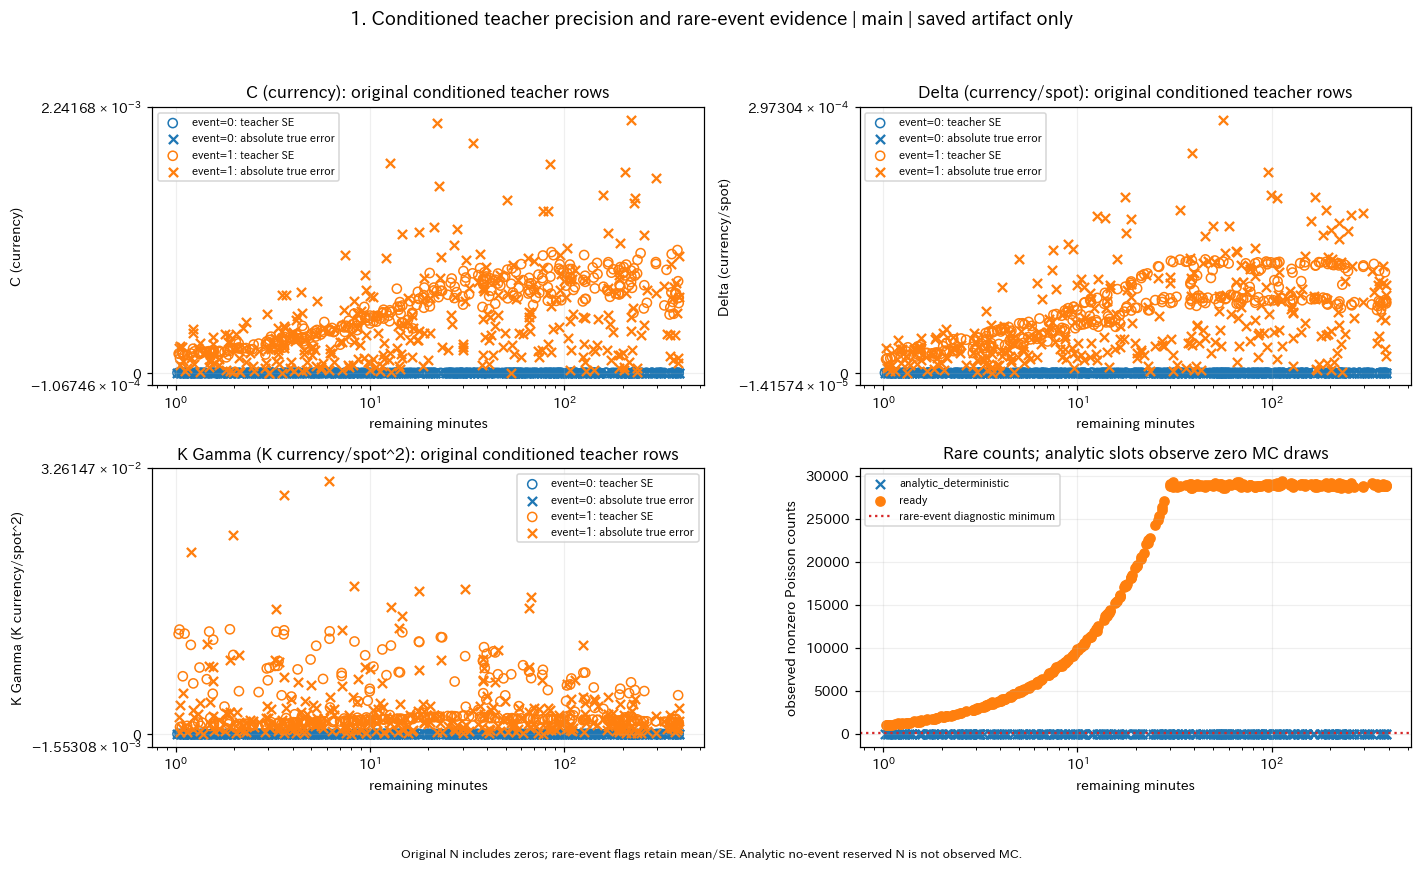

| split | original rows | teacher slots | reserved N | observed MC N | actual random draws | ready slots | all statuses |
| --- | --- | --- | --- | --- | --- | --- | --- |
| train | 512 | 512 | 536870912 | 268435456 | 272900160 | 512 | {'analytic_deterministic': 256, 'ready': 256} |
| validation | 128 | 128 | 134217728 | 67108864 | 68143766 | 128 | {'analytic_deterministic': 64, 'ready': 64} |

Teacher SE is an estimate; rare_event_unobserved/unresolved is not evidence of zero true error.


In [2]:
teacher_rows = []
teacher_tables = []
for split in ["train", "validation"]:
    dataset = record["datasets"][split]
    inputs = arrays[dataset["inputs_key"]]
    target = arrays[dataset["oracle_key"]]
    teachers = dataset["teachers"]
    for i, teacher in enumerate(teachers):
        teacher_rows.append((split, inputs[i], target[i], teacher,
                             arrays[teacher["keys"]["mean"]], arrays[teacher["keys"]["se"]]))
    teacher_tables.append([split, dataset["original_count"], len(teachers),
                           sum(t["reserved_sample_count"] for t in teachers),
                           sum(t["count"] for t in teachers),
                           sum(t["actual_random_draws"] for t in teachers),
                           sum(t["precision_ready"] for t in teachers),
                           dict(Counter(t["status"] for t in teachers))])
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for j, ax in enumerate(axes.flat[:3]):
    for event, color in [(0, "tab:blue"), (1, "tab:orange")]:
        rows = [row for row in teacher_rows if row[1][2] == event]
        if not rows:
            continue
        minutes = np.array([row[1][1]/60 for row in rows])
        standard_error = np.array([row[5][j]*scale[j] for row in rows])
        error = np.array([abs(row[4][j]-row[2][j])*scale[j] for row in rows])
        ax.scatter(minutes, standard_error, marker="o", facecolors="none", edgecolors=color,
                   label=f"event={event}: teacher SE")
        ax.scatter(minutes, error, marker="x", color=color,
                   label=f"event={event}: absolute true error")
    ax.set(xscale="log", yscale="symlog", xlabel="remaining minutes", ylabel=units[j],
           title=units[j] + ": original conditioned teacher rows")
    ax.grid(alpha=.2)
    ax.legend(fontsize=7)
ax = axes.flat[3]
for status in sorted({row[3]["status"] for row in teacher_rows}):
    rows = [row for row in teacher_rows if row[3]["status"] == status]
    ax.scatter([row[1][1]/60 for row in rows], [row[3]["active_count"] for row in rows],
               marker="x" if status == "analytic_deterministic" else "o", label=status)
ax.axhline(protocol["pilot"]["minimum_active_count"], linestyle=":", color="tab:red", label="rare-event diagnostic minimum")
ax.set(xscale="log", xlabel="remaining minutes", ylabel="observed nonzero Poisson counts",
       title="Rare counts; analytic slots observe zero MC draws")
ax.grid(alpha=.2)
ax.legend(fontsize=7)
finish_figure(fig, "1. Conditioned teacher precision and rare-event evidence",
              "Original N includes zeros; rare-event flags retain mean/SE. Analytic no-event reserved N is not observed MC.")
table(["split", "original rows", "teacher slots", "reserved N", "observed MC N", "actual random draws", "ready slots", "all statuses"], teacher_tables)
print("Teacher SE is an estimate; rare_event_unobserved/unresolved is not evidence of zero true error.")


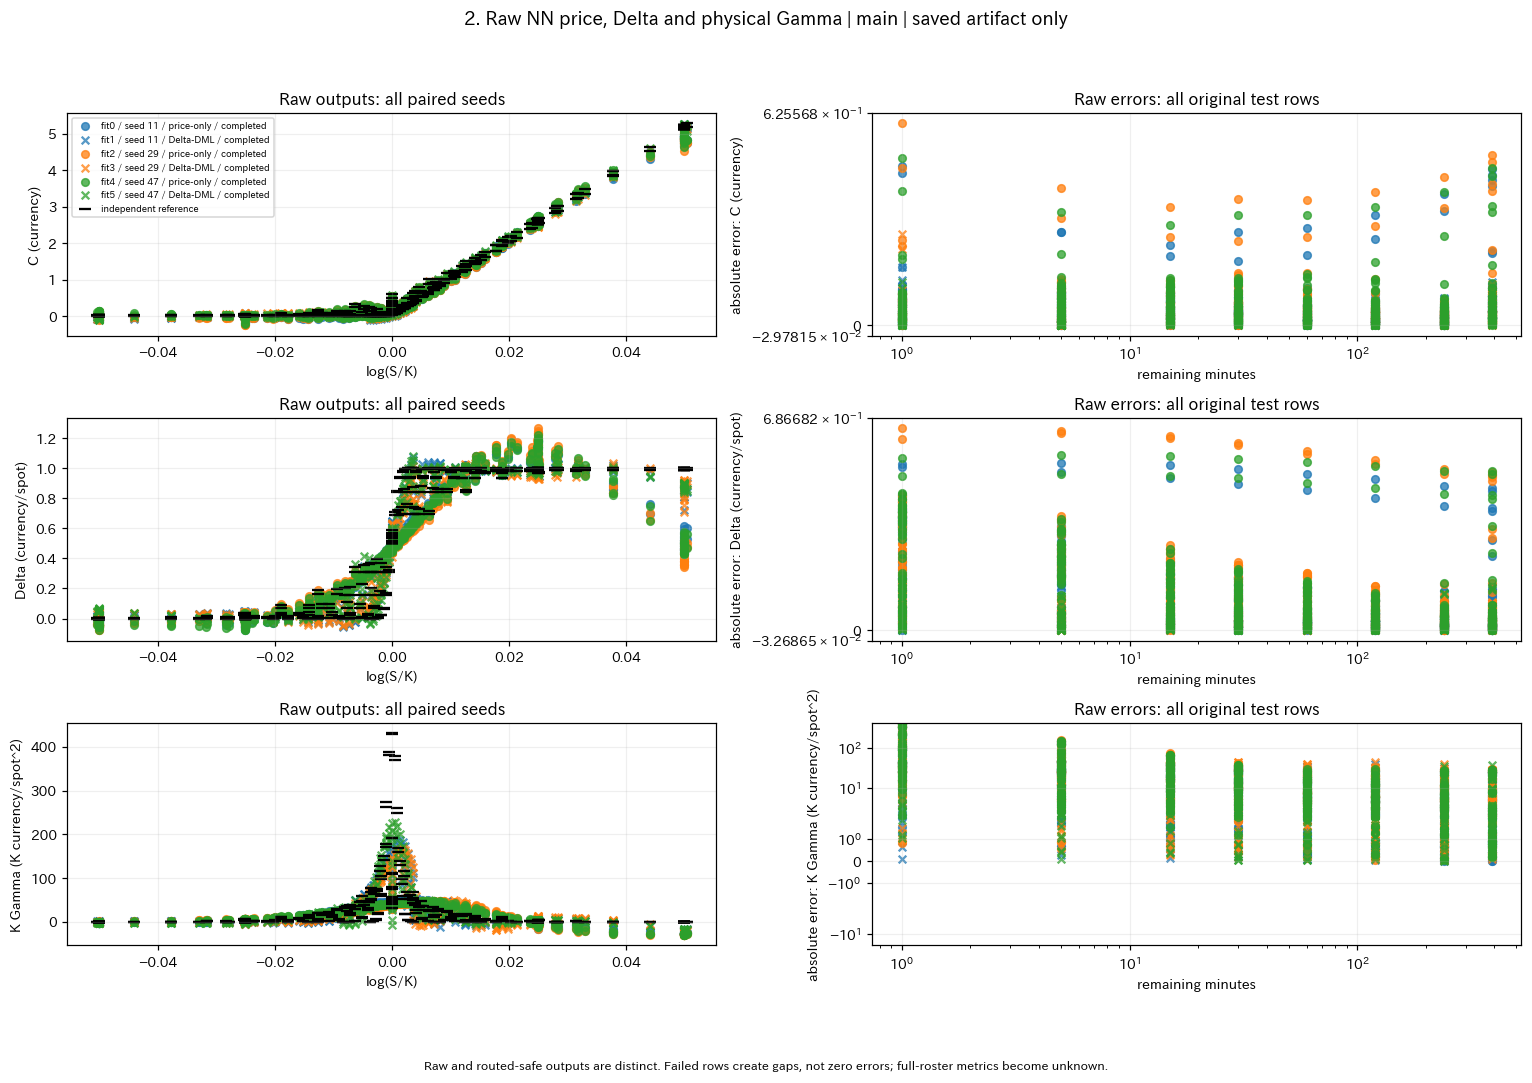

| fit | seed | method | status | reason | updates | batch attempts | original N | failed rows | RMSE C/Delta/KGamma | p99 C/Delta/KGamma | max C/Delta/KGamma |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| fit0 | 11 | price-only | completed | None | 512 | 512 | 336 | 0 | 0.096859, 0.18493, 60.453 | 0.43786, 0.52602, 333.25 | 0.47175, 0.54274, 388.68 |
| fit1 | 11 | Delta-DML | completed | None | 512 | 512 | 336 | 0 | 0.040505, 0.063156, 43.908 | 0.10735, 0.21321, 214.51 | 0.17226, 0.27587, 267.99 |
| fit2 | 29 | price-only | completed | None | 512 | 512 | 336 | 0 | 0.11156, 0.21095, 62.081 | 0.45572, 0.62754, 341.44 | 0.59578, 0.65398, 391.76 |
| fit3 | 29 | Delta-DML | completed | None | 512 | 512 | 336 | 0 | 0.042515, 0.073516, 47.214 | 0.11659, 0.27161, 242.71 | 0.27047, 0.30757, 289.31 |
| fit4 | 47 | price-only | completed | None | 512 | 512 | 336 | 0 | 0.097101, 0.19411, 61.218 | 0.39588, 0.55086, 339.27 | 0.49511, 0.56945, 389.65 |
| fit5 | 47 | Delta-DML | completed | None | 512 | 512 | 336 | 0 | 0.027818, 0.046492, 34.826 | 0.091591, 0.15584, 165.15 | 0.12732, 0.16079, 222.11 |

| fit | original contract diagnostic N | all routes | defined safe prices | defined ordinary Greeks |
| --- | --- | --- | --- | --- |
| fit0 | 10 | {'expiry_undefined_atm': 1, 'expiry_exact': 2, 'fallback_time': 2, 'fallback_spot': 1, 'invalid_contract': 4} | 6 | 5 |
| fit1 | 10 | {'expiry_undefined_atm': 1, 'expiry_exact': 2, 'fallback_time': 2, 'fallback_spot': 1, 'invalid_contract': 4} | 6 | 5 |
| fit2 | 10 | {'expiry_undefined_atm': 1, 'expiry_exact': 2, 'fallback_time': 2, 'fallback_spot': 1, 'invalid_contract': 4} | 6 | 5 |
| fit3 | 10 | {'expiry_undefined_atm': 1, 'expiry_exact': 2, 'fallback_time': 2, 'fallback_spot': 1, 'invalid_contract': 4} | 6 | 5 |
| fit4 | 10 | {'expiry_undefined_atm': 1, 'expiry_exact': 2, 'fallback_time': 2, 'fallback_spot': 1, 'invalid_contract': 4} | 6 | 5 |
| fit5 | 10 | {'expiry_undefined_atm': 1, 'expiry_exact': 2, 'fallback_time': 2, 'fallback_spot': 1, 'invalid_contract': 4} | 6 | 5 |

expiry_undefined_atm: price is defined; ordinary Greeks: unknown (Delta/Gamma NaN, reason retained).
Invalid contracts remain invalid; fallback output does not certify the accuracy of raw NN Greeks.


| fit | raw/safe | event | minutes | geometry | original N | failed rows | RMSE C/Delta/KGamma | p99 C/Delta/KGamma | max C/Delta/KGamma |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| fit0 | raw | 0 | 1 | all | 21 | 0 | 0.11946, 0.31972, 153.08 | 0.38543, 0.51019, 373.66 | 0.45098, 0.53985, 383.63 |
| fit0 | raw | 0 | 1 | atm | 7 | 0 | 0.095455, 0.26854, 261.31 | 0.1087, 0.36827, 380.64 | 0.10894, 0.36837, 383.63 |
| fit0 | raw | 0 | 1 | tail | 14 | 0 | 0.12981, 0.34245, 31.775 | 0.40838, 0.52057, 48.722 | 0.45098, 0.53985, 48.815 |
| fit0 | raw | 0 | 5 | all | 21 | 0 | 0.08689, 0.2332, 60.302 | 0.24099, 0.47513, 142.19 | 0.27674, 0.51387, 146.34 |
| fit0 | raw | 0 | 5 | atm | 8 | 0 | 0.070293, 0.23349, 89.031 | 0.097759, 0.31963, 144.89 | 0.098024, 0.32018, 146.34 |
| fit0 | raw | 0 | 5 | tail | 13 | 0 | 0.095683, 0.23302, 31.563 | 0.25522, 0.48544, 47.671 | 0.27674, 0.51387, 47.746 |
| fit0 | raw | 0 | 15 | all | 21 | 0 | 0.076414, 0.16504, 31.183 | 0.18296, 0.43839, 64.939 | 0.20473, 0.49261, 66.959 |
| fit0 | raw | 0 | 15 | atm | 7 | 0 | 0.051403, 0.16066, 41.009 | 0.075878, 0.22111, 66.353 | 0.076077, 0.22147, 66.959 |
| fit0 | raw | 0 | 15 | tail | 14 | 0 | 0.08624, 0.16718, 24.854 | 0.19058, 0.45295, 38.765 | 0.20473, 0.49261, 38.795 |
| fit0 | raw | 0 | 30 | all | 21 | 0 | 0.064235, 0.13979, 18.948 | 0.16939, 0.41477, 34.958 | 0.19081, 0.47541, 36.065 |
| fit0 | raw | 0 | 30 | atm | 7 | 0 | 0.032716, 0.10882, 21.866 | 0.046614, 0.14899, 35.733 | 0.04674, 0.15026, 36.065 |
| fit0 | raw | 0 | 30 | tail | 14 | 0 | 0.075193, 0.15293, 17.305 | 0.17689, 0.436, 29.278 | 0.19081, 0.47541, 29.408 |
| fit0 | raw | 0 | 60 | all | 21 | 0 | 0.064362, 0.12248, 10.958 | 0.1868, 0.39163, 25.621 | 0.20685, 0.45406, 27.298 |
| fit0 | raw | 0 | 60 | atm | 7 | 0 | 0.033201, 0.052279, 10.951 | 0.061657, 0.072041, 16.598 | 0.062809, 0.072154, 16.66 |
| fit0 | raw | 0 | 60 | tail | 14 | 0 | 0.07525, 0.14537, 10.962 | 0.19382, 0.41348, 26.208 | 0.20685, 0.45406, 27.298 |
| fit0 | raw | 0 | 120 | all | 21 | 0 | 0.065744, 0.10581, 9.3603 | 0.2202, 0.36258, 24.432 | 0.25545, 0.42903, 26.813 |
| fit0 | raw | 0 | 120 | atm | 9 | 0 | 0.030189, 0.040524, 8.9411 | 0.04623, 0.057536, 13.096 | 0.046368, 0.057675, 13.158 |
| fit0 | raw | 0 | 120 | tail | 12 | 0 | 0.082949, 0.1355, 9.6627 | 0.23606, 0.39249, 25.503 | 0.25545, 0.42903, 26.813 |
| fit0 | raw | 0 | 240 | all | 21 | 0 | 0.077822, 0.093477, 8.4047 | 0.27817, 0.3413, 24.229 | 0.33685, 0.40265, 25.42 |
| fit0 | raw | 0 | 240 | atm | 8 | 0 | 0.027172, 0.027947, 5.1831 | 0.043264, 0.038419, 7.3669 | 0.043466, 0.03843, 7.3752 |
| fit0 | raw | 0 | 240 | tail | 13 | 0 | 0.096586, 0.11677, 9.8781 | 0.3012, 0.36584, 24.705 | 0.33685, 0.40265, 25.42 |
| fit0 | raw | 0 | 390 | all | 21 | 0 | 0.15027, 0.13443, 9.8555 | 0.42521, 0.39335, 23.861 | 0.42846, 0.39533, 23.864 |
| fit0 | raw | 0 | 390 | atm | 11 | 0 | 0.070486, 0.016957, 1.6785 | 0.089759, 0.022702, 3.2028 | 0.090042, 0.022775, 3.2201 |
| fit0 | raw | 0 | 390 | tail | 10 | 0 | 0.20483, 0.19399, 14.173 | 0.427, 0.39444, 23.863 | 0.42846, 0.39533, 23.864 |
| fit0 | raw | 1 | 1 | all | 21 | 0 | 0.11969, 0.33077, 155.56 | 0.41186, 0.5101, 380.43 | 0.47175, 0.52824, 388.68 |
| fit0 | raw | 1 | 1 | atm | 7 | 0 | 0.066445, 0.27771, 266.38 | 0.079542, 0.41271, 386.2 | 0.079636, 0.41674, 388.68 |
| fit0 | raw | 1 | 1 | tail | 14 | 0 | 0.13886, 0.35434, 28.584 | 0.43282, 0.51645, 43.591 | 0.47175, 0.52824, 43.694 |
| fit0 | raw | 1 | 5 | all | 21 | 0 | 0.0895, 0.24457, 60.914 | 0.24289, 0.5017, 144.72 | 0.27633, 0.54274, 147.14 |
| fit0 | raw | 1 | 5 | atm | 8 | 0 | 0.080775, 0.24264, 90.865 | 0.10912, 0.33667, 146.29 | 0.10913, 0.33751, 147.14 |
| fit0 | raw | 1 | 5 | tail | 13 | 0 | 0.094469, 0.24574, 30.217 | 0.25555, 0.51237, 45.658 | 0.27633, 0.54274, 45.721 |
| fit0 | raw | 1 | 15 | all | 21 | 0 | 0.081338, 0.17332, 31.261 | 0.21338, 0.47565, 64.263 | 0.23814, 0.53681, 64.537 |
| fit0 | raw | 1 | 15 | atm | 7 | 0 | 0.071477, 0.16473, 41.576 | 0.099793, 0.23031, 64.455 | 0.10009, 0.23097, 64.537 |
| fit0 | raw | 1 | 15 | tail | 14 | 0 | 0.085844, 0.17746, 24.527 | 0.22205, 0.49123, 38.698 | 0.23814, 0.53681, 38.882 |
| fit0 | raw | 1 | 30 | all | 21 | 0 | 0.08073, 0.14998, 19.059 | 0.24236, 0.45216, 34.424 | 0.27645, 0.52191, 35.09 |
| fit0 | raw | 1 | 30 | atm | 7 | 0 | 0.044252, 0.11433, 22.955 | 0.080396, 0.16503, 34.891 | 0.082616, 0.16535, 35.09 |
| fit0 | raw | 1 | 30 | tail | 14 | 0 | 0.093791, 0.16494, 16.775 | 0.25429, 0.47658, 30.591 | 0.27645, 0.52191, 30.859 |
| fit0 | raw | 1 | 60 | all | 21 | 0 | 0.076553, 0.13222, 11.289 | 0.25333, 0.43454, 25.907 | 0.2887, 0.5074, 27.497 |
| fit0 | raw | 1 | 60 | atm | 7 | 0 | 0.036982, 0.055731, 12.053 | 0.071466, 0.091246, 19.305 | 0.072432, 0.092454, 19.548 |
| fit0 | raw | 1 | 60 | tail | 14 | 0 | 0.090038, 0.15707, 10.887 | 0.26571, 0.46004, 26.359 | 0.2887, 0.5074, 27.497 |
| fit0 | raw | 1 | 120 | all | 21 | 0 | 0.079346, 0.11828, 9.8739 | 0.27921, 0.41177, 25.172 | 0.32561, 0.48856, 26.899 |
| fit0 | raw | 1 | 120 | atm | 9 | 0 | 0.028527, 0.044657, 9.2928 | 0.050242, 0.072523, 14.686 | 0.051165, 0.073885, 14.851 |
| fit0 | raw | 1 | 120 | tail | 12 | 0 | 0.10202, 0.15162, 10.288 | 0.30009, 0.44633, 25.949 | 0.32561, 0.48856, 26.899 |
| fit0 | raw | 1 | 240 | all | 21 | 0 | 0.088217, 0.11007, 9.5565 | 0.31996, 0.39898, 25.495 | 0.38643, 0.46713, 25.954 |
| fit0 | raw | 1 | 240 | atm | 8 | 0 | 0.031774, 0.033827, 5.8074 | 0.053919, 0.053975, 9.1958 | 0.054105, 0.054245, 9.2996 |
| fit0 | raw | 1 | 240 | tail | 13 | 0 | 0.10932, 0.13736, 11.259 | 0.34433, 0.42624, 25.679 | 0.38643, 0.46713, 25.954 |
| fit0 | raw | 1 | 390 | all | 21 | 0 | 0.16065, 0.15955, 11.411 | 0.45811, 0.45993, 25.705 | 0.46191, 0.46201, 25.867 |
| fit0 | raw | 1 | 390 | atm | 11 | 0 | 0.078462, 0.035144, 3.6668 | 0.12196, 0.057924, 5.8729 | 0.12306, 0.058997, 5.9288 |
| fit0 | raw | 1 | 390 | tail | 10 | 0 | 0.21778, 0.22825, 16.082 | 0.4602, 0.46107, 25.794 | 0.46191, 0.46201, 25.867 |
| fit0 | safe | 0 | 1 | all | 21 | 0 | 0.06023, 0.27761, 152.33 | 0.10814, 0.39088, 373.66 | 0.10894, 0.39154, 383.63 |
| fit0 | safe | 0 | 1 | atm | 7 | 0 | 0.095455, 0.26854, 261.31 | 0.1087, 0.36827, 380.64 | 0.10894, 0.36837, 383.63 |
| fit0 | safe | 0 | 1 | tail | 14 | 0 | 0.029758, 0.28204, 25.794 | 0.060619, 0.39111, 47.598 | 0.060619, 0.39154, 48.097 |
| fit0 | safe | 0 | 5 | all | 21 | 0 | 0.043728, 0.13938, 54.769 | 0.097266, 0.31206, 142.19 | 0.098024, 0.32018, 146.34 |
| fit0 | safe | 0 | 5 | atm | 8 | 0 | 0.070287, 0.20571, 88.625 | 0.097759, 0.31733, 144.89 | 0.098024, 0.32018, 146.34 |
| fit0 | safe | 0 | 5 | tail | 13 | 0 | 0.0069748, 0.073076, 3.4714 | 0.02213, 0.23186, 11.014 | 0.025148, 0.26348, 12.516 |
| fit0 | safe | 0 | 15 | all | 21 | 0 | 0.029489, 0.079171, 23.541 | 0.075413, 0.20823, 64.939 | 0.076077, 0.21543, 66.959 |
| fit0 | safe | 0 | 15 | atm | 7 | 0 | 0.051076, 0.13713, 40.774 | 0.075878, 0.21327, 66.353 | 0.076077, 0.21543, 66.959 |
| fit0 | safe | 0 | 15 | tail | 14 | 0 | 0, 0, 0 | 0, 0, 0 | 0, 0, 0 |
| fit0 | safe | 0 | 30 | all | 21 | 0 | 0.016182, 0.056154, 12.014 | 0.046227, 0.1442, 34.958 | 0.04674, 0.15026, 36.065 |
| fit0 | safe | 0 | 30 | atm | 7 | 0 | 0.028027, 0.097262, 20.808 | 0.046586, 0.14844, 35.733 | 0.04674, 0.15026, 36.065 |
| fit0 | safe | 0 | 30 | tail | 14 | 0 | 0, 0, 0 | 0, 0, 0 | 0, 0, 0 |
| fit0 | safe | 0 | 60 | all | 21 | 0 | 0.010741, 0.026884, 5.0409 | 0.03823, 0.071778, 15.193 | 0.043609, 0.072154, 15.633 |
| fit0 | safe | 0 | 60 | atm | 7 | 0 | 0.018604, 0.046565, 8.7311 | 0.041995, 0.072041, 15.501 | 0.043609, 0.072154, 15.633 |
| fit0 | safe | 0 | 60 | tail | 14 | 0 | 0, 0, 0 | 0, 0, 0 | 0, 0, 0 |
| fit0 | safe | 0 | 120 | all | 21 | 0 | 0.0074386, 0.022431, 3.8476 | 0.025672, 0.057326, 11.755 | 0.029545, 0.057675, 12.174 |
| fit0 | safe | 0 | 120 | atm | 9 | 0 | 0.011363, 0.034264, 5.8773 | 0.027996, 0.057536, 12.006 | 0.029545, 0.057675, 12.174 |
| fit0 | safe | 0 | 120 | tail | 12 | 0 | 0, 0, 0 | 0, 0, 0 | 0, 0, 0 |
| fit0 | safe | 0 | 240 | all | 21 | 0 | 0.0080142, 0.015222, 2.2696 | 0.0279, 0.038397, 7.0312 | 0.030763, 0.03843, 7.3752 |
| fit0 | safe | 0 | 240 | atm | 8 | 0 | 0.012984, 0.024663, 3.6772 | 0.029761, 0.038419, 7.2548 | 0.030763, 0.03843, 7.3752 |
| fit0 | safe | 0 | 240 | tail | 13 | 0 | 0, 0, 0 | 0, 0, 0 | 0, 0, 0 |
| fit0 | safe | 0 | 390 | all | 21 | 0 | 0.040415, 0.0060663, 0.66302 | 0.089475, 0.01841, 2.0228 | 0.090042, 0.019536, 2.1369 |
| fit0 | safe | 0 | 390 | atm | 11 | 0 | 0.055841, 0.0083818, 0.9161 | 0.089759, 0.018973, 2.0799 | 0.090042, 0.019536, 2.1369 |
| fit0 | safe | 0 | 390 | tail | 10 | 0 | 0, 0, 0 | 0, 0, 0 | 0, 0, 0 |
| fit0 | safe | 1 | 1 | all | 21 | 0 | 0.039903, 0.24924, 154.22 | 0.079322, 0.43656, 380.43 | 0.079636, 0.43757, 388.68 |
| fit0 | safe | 1 | 1 | atm | 7 | 0 | 0.066445, 0.27771, 266.38 | 0.079542, 0.41271, 386.2 | 0.079636, 0.41674, 388.68 |
| fit0 | safe | 1 | 1 | tail | 14 | 0 | 0.013452, 0.23371, 14.047 | 0.03695, 0.43691, 31.698 | 0.039137, 0.43757, 32.481 |
| fit0 | safe | 1 | 5 | all | 21 | 0 | 0.050952, 0.17629, 56.719 | 0.10912, 0.33511, 144.72 | 0.10913, 0.33751, 147.14 |
| fit0 | safe | 1 | 5 | atm | 8 | 0 | 0.080775, 0.24264, 90.865 | 0.10912, 0.33667, 146.29 | 0.10913, 0.33751, 147.14 |
| fit0 | safe | 1 | 5 | tail | 13 | 0 | 0.013365, 0.11821, 10.763 | 0.041147, 0.26397, 29.256 | 0.044352, 0.26596, 29.959 |
| fit0 | safe | 1 | 15 | all | 21 | 0 | 0.045739, 0.11753, 27.377 | 0.099107, 0.22878, 64.263 | 0.10009, 0.23097, 64.537 |
| fit0 | safe | 1 | 15 | atm | 7 | 0 | 0.071477, 0.16473, 41.576 | 0.099793, 0.23031, 64.455 | 0.10009, 0.23097, 64.537 |
| fit0 | safe | 1 | 15 | tail | 14 | 0 | 0.024159, 0.084566, 16.122 | 0.066592, 0.1708, 38.284 | 0.069811, 0.17091, 38.882 |
| fit0 | safe | 1 | 30 | all | 21 | 0 | 0.035942, 0.071714, 15.508 | 0.099878, 0.16427, 34.424 | 0.10419, 0.16535, 35.09 |
| fit0 | safe | 1 | 30 | atm | 7 | 0 | 0.044252, 0.11433, 22.955 | 0.080396, 0.16503, 34.891 | 0.082616, 0.16535, 35.09 |
| fit0 | safe | 1 | 30 | tail | 14 | 0 | 0.030962, 0.034334, 9.8633 | 0.095971, 0.090811, 28.586 | 0.10419, 0.094503, 30.859 |
| fit0 | safe | 1 | 60 | all | 21 | 0 | 0.023081, 0.033233, 7.3072 | 0.069212, 0.088426, 18.736 | 0.072432, 0.092454, 19.548 |
| fit0 | safe | 1 | 60 | atm | 7 | 0 | 0.036982, 0.055731, 12.053 | 0.071466, 0.091246, 19.305 | 0.072432, 0.092454, 19.548 |
| fit0 | safe | 1 | 60 | tail | 14 | 0 | 0.010737, 0.010183, 2.7301 | 0.025757, 0.032134, 6.6749 | 0.025793, 0.035197, 6.7729 |
| fit0 | safe | 1 | 120 | all | 21 | 0 | 0.017909, 0.026628, 5.5495 | 0.048856, 0.069768, 14.226 | 0.051165, 0.073885, 14.851 |
| fit0 | safe | 1 | 120 | atm | 9 | 0 | 0.02529, 0.040434, 8.2572 | 0.050242, 0.072238, 14.601 | 0.051165, 0.073885, 14.851 |
| fit0 | safe | 1 | 120 | tail | 12 | 0 | 0.0090334, 0.003821, 1.6611 | 0.01866, 0.011035, 4.3743 | 0.018711, 0.01172, 4.576 |
| fit0 | safe | 1 | 240 | all | 21 | 0 | 0.021199, 0.017837, 3.4267 | 0.053574, 0.048727, 9.0029 | 0.054105, 0.050382, 9.2996 |
| fit0 | safe | 1 | 240 | atm | 8 | 0 | 0.029045, 0.027865, 5.4462 | 0.053919, 0.049803, 9.1958 | 0.054105, 0.050382, 9.2996 |
| fit0 | safe | 1 | 240 | tail | 13 | 0 | 0.014381, 0.006011, 0.84528 | 0.026362, 0.016966, 1.942 | 0.026507, 0.018061, 1.9728 |
| fit0 | safe | 1 | 390 | all | 21 | 0 | 0.055188, 0.020734, 2.1024 | 0.12087, 0.055444, 5.7859 | 0.12306, 0.058997, 5.9288 |
| fit0 | safe | 1 | 390 | atm | 11 | 0 | 0.076253, 0.028649, 2.9048 | 0.12196, 0.057221, 5.8573 | 0.12306, 0.058997, 5.9288 |
| fit0 | safe | 1 | 390 | tail | 10 | 0 | 0, 0, 0 | 0, 0, 0 | 0, 0, 0 |
| fit1 | raw | 0 | 1 | all | 21 | 0 | 0.042488, 0.13269, 118.63 | 0.1281, 0.26604, 251.04 | 0.13498, 0.27587, 258.67 |
| fit1 | raw | 0 | 1 | atm | 7 | 0 | 0.020354, 0.16181, 158.63 | 0.027545, 0.22641, 256.38 | 0.027574, 0.22669, 258.67 |
| fit1 | raw | 0 | 1 | tail | 14 | 0 | 0.050006, 0.1154, 92.353 | 0.13051, 0.26401, 153.11 | 0.13498, 0.27587, 153.37 |
| fit1 | raw | 0 | 5 | all | 21 | 0 | 0.029481, 0.056286, 22.003 | 0.079065, 0.16804, 46.65 | 0.085515, 0.19093, 47.522 |
| fit1 | raw | 0 | 5 | atm | 8 | 0 | 0.024031, 0.05052, 29.342 | 0.032342, 0.076084, 47.217 | 0.032392, 0.076503, 47.522 |
| fit1 | raw | 0 | 5 | tail | 13 | 0 | 0.032382, 0.059558, 15.882 | 0.081645, 0.17442, 27.229 | 0.085515, 0.19093, 27.252 |
| fit1 | raw | 0 | 15 | all | 21 | 0 | 0.032356, 0.038254, 10.676 | 0.057391, 0.12657, 24.952 | 0.060058, 0.14567, 25.542 |
| fit1 | raw | 0 | 15 | atm | 7 | 0 | 0.029818, 0.021305, 12.464 | 0.035149, 0.044627, 24.997 | 0.035314, 0.045784, 25.542 |
| fit1 | raw | 0 | 15 | tail | 14 | 0 | 0.033553, 0.044363, 9.659 | 0.058324, 0.13326, 22.163 | 0.060058, 0.14567, 22.592 |
| fit1 | raw | 0 | 30 | all | 21 | 0 | 0.033252, 0.038082, 13.183 | 0.06839, 0.11307, 31.467 | 0.07443, 0.12458, 32.88 |
| fit1 | raw | 0 | 30 | atm | 7 | 0 | 0.02653, 0.042554, 19.464 | 0.039407, 0.06619, 32.456 | 0.039823, 0.067045, 32.88 |
| fit1 | raw | 0 | 30 | tail | 14 | 0 | 0.036148, 0.035637, 8.4407 | 0.070504, 0.11149, 21.857 | 0.07443, 0.12458, 22.647 |
| fit1 | raw | 0 | 60 | all | 21 | 0 | 0.032271, 0.04145, 13.833 | 0.076403, 0.10414, 34.655 | 0.085946, 0.10905, 35.797 |
| fit1 | raw | 0 | 60 | atm | 7 | 0 | 0.02023, 0.055141, 21.095 | 0.025808, 0.083653, 35.454 | 0.025871, 0.084502, 35.797 |
| fit1 | raw | 0 | 60 | tail | 14 | 0 | 0.036844, 0.03251, 8.0342 | 0.079743, 0.098484, 20.667 | 0.085946, 0.10905, 22.037 |
| fit1 | raw | 0 | 120 | all | 21 | 0 | 0.038394, 0.040103, 13.207 | 0.071411, 0.10674, 37.177 | 0.074358, 0.10875, 39.99 |
| fit1 | raw | 0 | 120 | atm | 9 | 0 | 0.03634, 0.046598, 18.478 | 0.058873, 0.10424, 38.865 | 0.059622, 0.10875, 39.99 |
| fit1 | raw | 0 | 120 | tail | 12 | 0 | 0.039865, 0.034437, 7.012 | 0.072424, 0.091339, 19.173 | 0.074358, 0.098698, 20.638 |
| fit1 | raw | 0 | 240 | all | 21 | 0 | 0.042142, 0.042236, 11.833 | 0.075199, 0.11649, 30.599 | 0.077629, 0.12217, 31.84 |
| fit1 | raw | 0 | 240 | atm | 8 | 0 | 0.045269, 0.051065, 17.718 | 0.076779, 0.11755, 31.406 | 0.077629, 0.12217, 31.84 |
| fit1 | raw | 0 | 240 | tail | 13 | 0 | 0.040097, 0.035734, 5.7466 | 0.064133, 0.086839, 16.875 | 0.064753, 0.093785, 18.408 |
| fit1 | raw | 0 | 390 | all | 21 | 0 | 0.044964, 0.054613, 9.0322 | 0.084655, 0.12091, 20.9 | 0.088875, 0.12444, 21.808 |
| fit1 | raw | 0 | 390 | atm | 11 | 0 | 0.047501, 0.060308, 9.8904 | 0.086374, 0.12268, 21.354 | 0.088875, 0.12444, 21.808 |
| fit1 | raw | 0 | 390 | tail | 10 | 0 | 0.041998, 0.047567, 7.9822 | 0.067718, 0.1004, 16.828 | 0.067775, 0.10102, 16.871 |
| fit1 | raw | 1 | 1 | all | 21 | 0 | 0.078878, 0.13372, 119.3 | 0.157, 0.21364, 261.25 | 0.17226, 0.21422, 267.99 |
| fit1 | raw | 1 | 1 | atm | 7 | 0 | 0.056039, 0.16635, 165.93 | 0.068043, 0.21405, 265.97 | 0.068335, 0.21422, 267.99 |
| fit1 | raw | 1 | 1 | tail | 14 | 0 | 0.088105, 0.11395, 87.078 | 0.16234, 0.19886, 136.02 | 0.17226, 0.20013, 136.15 |
| fit1 | raw | 1 | 5 | all | 21 | 0 | 0.012083, 0.049066, 22.275 | 0.040808, 0.12765, 43.077 | 0.047817, 0.14534, 43.177 |
| fit1 | raw | 1 | 5 | atm | 8 | 0 | 0.0069345, 0.042086, 29.505 | 0.011419, 0.056911, 43.142 | 0.011434, 0.056912, 43.177 |
| fit1 | raw | 1 | 5 | tail | 13 | 0 | 0.014361, 0.052905, 16.303 | 0.043611, 0.13427, 29.654 | 0.047817, 0.14534, 29.793 |
| fit1 | raw | 1 | 15 | all | 21 | 0 | 0.023644, 0.033735, 7.7427 | 0.051545, 0.11428, 21.831 | 0.055667, 0.1344, 22.81 |
| fit1 | raw | 1 | 15 | atm | 7 | 0 | 0.019722, 0.015501, 8.9666 | 0.022115, 0.028494, 17.516 | 0.022138, 0.029098, 17.914 |
| fit1 | raw | 1 | 15 | tail | 14 | 0 | 0.025379, 0.039837, 7.0515 | 0.052988, 0.12132, 20.914 | 0.055667, 0.1344, 22.81 |
| fit1 | raw | 1 | 30 | all | 21 | 0 | 0.027863, 0.038775, 11.282 | 0.042371, 0.11667, 22.472 | 0.042384, 0.12925, 22.754 |
| fit1 | raw | 1 | 30 | atm | 7 | 0 | 0.025965, 0.041777, 16.629 | 0.037665, 0.065076, 21.34 | 0.038052, 0.066355, 21.343 |
| fit1 | raw | 1 | 30 | tail | 14 | 0 | 0.028765, 0.037182, 7.2567 | 0.042376, 0.11737, 20.835 | 0.042384, 0.12925, 22.754 |
| fit1 | raw | 1 | 60 | all | 21 | 0 | 0.021455, 0.042797, 12.367 | 0.047116, 0.12076, 32.406 | 0.048333, 0.13142, 33.546 |
| fit1 | raw | 1 | 60 | atm | 7 | 0 | 0.030587, 0.048543, 19.155 | 0.047968, 0.07767, 33.204 | 0.048333, 0.078082, 33.546 |
| fit1 | raw | 1 | 60 | tail | 14 | 0 | 0.014923, 0.039614, 6.7804 | 0.035379, 0.11948, 20.192 | 0.036499, 0.13142, 22.126 |
| fit1 | raw | 1 | 120 | all | 21 | 0 | 0.018653, 0.041445, 12.068 | 0.051146, 0.12483, 32.96 | 0.055759, 0.13371, 34.501 |
| fit1 | raw | 1 | 120 | atm | 9 | 0 | 0.014136, 0.039784, 16.947 | 0.031366, 0.08645, 33.884 | 0.032698, 0.089313, 34.501 |
| fit1 | raw | 1 | 120 | tail | 12 | 0 | 0.021424, 0.042648, 6.2818 | 0.052935, 0.12239, 19.059 | 0.055759, 0.13371, 21.035 |
| fit1 | raw | 1 | 240 | all | 21 | 0 | 0.032633, 0.043166, 11.127 | 0.076646, 0.12857, 26.317 | 0.080417, 0.13592, 26.521 |
| fit1 | raw | 1 | 240 | atm | 8 | 0 | 0.02107, 0.044741, 16.509 | 0.043391, 0.095634, 26.45 | 0.044675, 0.099139, 26.521 |
| fit1 | raw | 1 | 240 | tail | 13 | 0 | 0.03804, 0.042167, 5.6796 | 0.078155, 0.12322, 17.689 | 0.080417, 0.13592, 19.515 |
| fit1 | raw | 1 | 390 | all | 21 | 0 | 0.074386, 0.060812, 8.7365 | 0.12481, 0.14387, 21.071 | 0.12906, 0.1454, 21.697 |
| fit1 | raw | 1 | 390 | atm | 11 | 0 | 0.068759, 0.054868, 8.5577 | 0.1268, 0.10662, 20.72 | 0.12906, 0.10742, 21.697 |
| fit1 | raw | 1 | 390 | tail | 10 | 0 | 0.080122, 0.066741, 8.9291 | 0.10731, 0.14471, 18.532 | 0.10784, 0.1454, 18.565 |
| fit1 | safe | 0 | 1 | all | 21 | 0 | 0.011841, 0.10346, 94.18 | 0.027478, 0.22575, 251.04 | 0.027574, 0.22669, 258.67 |
| fit1 | safe | 0 | 1 | atm | 7 | 0 | 0.020354, 0.16181, 158.63 | 0.027545, 0.22641, 256.38 | 0.027574, 0.22669, 258.67 |
| fit1 | safe | 0 | 1 | tail | 14 | 0 | 0.0017801, 0.054464, 26.902 | 0.0057955, 0.15557, 79.279 | 0.0066605, 0.15995, 82.51 |
| fit1 | safe | 0 | 5 | all | 21 | 0 | 0.015961, 0.031777, 20.427 | 0.03225, 0.075306, 46.65 | 0.032392, 0.076503, 47.522 |
| fit1 | safe | 0 | 5 | atm | 8 | 0 | 0.024031, 0.05052, 29.342 | 0.032342, 0.076084, 47.217 | 0.032392, 0.076503, 47.522 |
| fit1 | safe | 0 | 5 | tail | 13 | 0 | 0.0074932, 0.0077814, 12.008 | 0.019055, 0.024898, 27.229 | 0.019221, 0.027812, 27.252 |
| fit1 | safe | 0 | 15 | all | 21 | 0 | 0.019219, 0.017233, 8.7392 | 0.034763, 0.049313, 24.292 | 0.035314, 0.050195, 25.542 |
| fit1 | safe | 0 | 15 | atm | 7 | 0 | 0.029818, 0.021305, 12.464 | 0.035149, 0.044627, 24.997 | 0.035314, 0.045784, 25.542 |
| fit1 | safe | 0 | 15 | tail | 14 | 0 | 0.010465, 0.014783, 6.0736 | 0.028271, 0.046087, 18.209 | 0.029314, 0.050195, 19.291 |
| fit1 | safe | 0 | 30 | all | 21 | 0 | 0.018542, 0.025518, 11.85 | 0.038612, 0.064194, 31.467 | 0.039823, 0.067045, 32.88 |
| fit1 | safe | 0 | 30 | atm | 7 | 0 | 0.02653, 0.042554, 19.464 | 0.039407, 0.06619, 32.456 | 0.039823, 0.067045, 32.88 |
| fit1 | safe | 0 | 30 | tail | 14 | 0 | 0.012799, 0.0084444, 4.604 | 0.032329, 0.02202, 14.868 | 0.033766, 0.02222, 16.574 |
| fit1 | safe | 0 | 60 | all | 21 | 0 | 0.017204, 0.032324, 12.472 | 0.032278, 0.081673, 34.655 | 0.032671, 0.084502, 35.797 |
| fit1 | safe | 0 | 60 | atm | 7 | 0 | 0.02023, 0.055141, 21.095 | 0.025808, 0.083653, 35.454 | 0.025871, 0.084502, 35.797 |
| fit1 | safe | 0 | 60 | tail | 14 | 0 | 0.015471, 0.0068518, 3.2922 | 0.032416, 0.020317, 7.4244 | 0.032671, 0.021243, 7.4396 |
| fit1 | safe | 0 | 120 | all | 21 | 0 | 0.025121, 0.031825, 11.833 | 0.049488, 0.097482, 37.177 | 0.050256, 0.10875, 39.99 |
| fit1 | safe | 0 | 120 | atm | 9 | 0 | 0.030424, 0.0463, 17.932 | 0.049866, 0.10424, 38.865 | 0.050256, 0.10875, 39.99 |
| fit1 | safe | 0 | 120 | tail | 12 | 0 | 0.020253, 0.01283, 1.9711 | 0.046161, 0.022328, 5.0551 | 0.046414, 0.022356, 5.2111 |
| fit1 | safe | 0 | 240 | all | 21 | 0 | 0.031759, 0.034827, 10.75 | 0.065333, 0.10896, 30.599 | 0.065478, 0.12217, 31.84 |
| fit1 | safe | 0 | 240 | atm | 8 | 0 | 0.036, 0.050982, 17.215 | 0.064779, 0.11755, 31.406 | 0.065478, 0.12217, 31.84 |
| fit1 | safe | 0 | 240 | tail | 13 | 0 | 0.028841, 0.01897, 2.0771 | 0.064133, 0.035775, 5.278 | 0.064753, 0.035907, 5.3819 |
| fit1 | safe | 0 | 390 | all | 21 | 0 | 0.033184, 0.043447, 6.1638 | 0.083797, 0.12091, 19.121 | 0.088875, 0.12444, 21.808 |
| fit1 | safe | 0 | 390 | atm | 11 | 0 | 0.043423, 0.059643, 8.4091 | 0.086336, 0.12268, 20.465 | 0.088875, 0.12444, 21.808 |
| fit1 | safe | 0 | 390 | tail | 10 | 0 | 0.01544, 0.0071403, 1.4145 | 0.036875, 0.020607, 3.9928 | 0.037419, 0.022565, 4.2497 |
| fit1 | safe | 1 | 1 | all | 21 | 0 | 0, 0, 0 | 0, 0, 0 | 0, 0, 0 |
| fit1 | safe | 1 | 1 | atm | 7 | 0 | 0, 0, 0 | 0, 0, 0 | 0, 0, 0 |
| fit1 | safe | 1 | 1 | tail | 14 | 0 | 0, 0, 0 | 0, 0, 0 | 0, 0, 0 |
| fit1 | safe | 1 | 5 | all | 21 | 0 | 0.0045177, 0.027054, 20.321 | 0.011392, 0.056911, 43.077 | 0.011434, 0.056912, 43.177 |
| fit1 | safe | 1 | 5 | atm | 8 | 0 | 0.0069345, 0.042086, 29.505 | 0.011419, 0.056911, 43.142 | 0.011434, 0.056912, 43.177 |
| fit1 | safe | 1 | 5 | tail | 13 | 0 | 0.0018377, 0.0096072, 11.46 | 0.0053252, 0.03074, 29.654 | 0.0055599, 0.03448, 29.793 |
| fit1 | safe | 1 | 15 | all | 21 | 0 | 0.014175, 0.011461, 5.7031 | 0.025206, 0.028508, 16.589 | 0.025628, 0.029098, 17.914 |
| fit1 | safe | 1 | 15 | atm | 7 | 0 | 0.019722, 0.015501, 8.9666 | 0.022115, 0.028494, 17.516 | 0.022138, 0.029098, 17.914 |
| fit1 | safe | 1 | 15 | tail | 14 | 0 | 0.01034, 0.0087683, 2.9305 | 0.025354, 0.024508, 8.0542 | 0.025628, 0.026147, 8.2283 |
| fit1 | safe | 1 | 30 | all | 21 | 0 | 0.022319, 0.024577, 9.9945 | 0.042371, 0.062093, 21.331 | 0.042384, 0.066355, 21.343 |
| fit1 | safe | 1 | 30 | atm | 7 | 0 | 0.025965, 0.041777, 16.629 | 0.037665, 0.065076, 21.34 | 0.038052, 0.066355, 21.343 |
| fit1 | safe | 1 | 30 | tail | 14 | 0 | 0.020252, 0.0057746, 3.4022 | 0.042376, 0.018367, 7.9737 | 0.042384, 0.020201, 7.9904 |
| fit1 | safe | 1 | 60 | all | 21 | 0 | 0.018424, 0.029017, 11.217 | 0.047116, 0.076708, 32.406 | 0.048333, 0.078082, 33.546 |
| fit1 | safe | 1 | 60 | atm | 7 | 0 | 0.030587, 0.048543, 19.155 | 0.047968, 0.07767, 33.204 | 0.048333, 0.078082, 33.546 |
| fit1 | safe | 1 | 60 | tail | 14 | 0 | 0.0064321, 0.0092084, 2.3011 | 0.015335, 0.014641, 6.7672 | 0.015739, 0.014642, 7.2511 |
| fit1 | safe | 1 | 120 | all | 21 | 0 | 0.013334, 0.028116, 11.026 | 0.032177, 0.082157, 32.96 | 0.032698, 0.089313, 34.501 |
| fit1 | safe | 1 | 120 | atm | 9 | 0 | 0.014129, 0.039597, 16.796 | 0.031366, 0.08645, 33.884 | 0.032698, 0.089313, 34.501 |
| fit1 | safe | 1 | 120 | tail | 12 | 0 | 0.012705, 0.014404, 1.0897 | 0.029249, 0.023354, 2.3679 | 0.030093, 0.023398, 2.395 |
| fit1 | safe | 1 | 240 | all | 21 | 0 | 0.015742, 0.029701, 10.19 | 0.04164, 0.089125, 26.317 | 0.044675, 0.099139, 26.521 |
| fit1 | safe | 1 | 240 | atm | 8 | 0 | 0.020864, 0.044738, 16.39 | 0.043391, 0.095634, 26.45 | 0.044675, 0.099139, 26.521 |
| fit1 | safe | 1 | 240 | tail | 13 | 0 | 0.011507, 0.013903, 1.5603 | 0.029007, 0.03001, 4.0817 | 0.029502, 0.030079, 4.3007 |
| fit1 | safe | 1 | 390 | all | 21 | 0 | 0.050004, 0.039466, 5.6386 | 0.12454, 0.10581, 18.994 | 0.12906, 0.10742, 21.697 |
| fit1 | safe | 1 | 390 | atm | 11 | 0 | 0.068632, 0.054344, 7.7657 | 0.1268, 0.10662, 20.346 | 0.12906, 0.10742, 21.697 |
| fit1 | safe | 1 | 390 | tail | 10 | 0 | 0.008335, 0.0047246, 0.65622 | 0.023985, 0.013596, 1.8884 | 0.026358, 0.014941, 2.0752 |
| fit2 | raw | 0 | 1 | all | 21 | 0 | 0.12858, 0.3463, 156.78 | 0.42187, 0.60856, 381.84 | 0.46452, 0.65398, 391.76 |
| fit2 | raw | 0 | 1 | atm | 7 | 0 | 0.081366, 0.27705, 268.68 | 0.094822, 0.39941, 388.79 | 0.094998, 0.40223, 391.76 |
| fit2 | raw | 0 | 1 | tail | 14 | 0 | 0.1466, 0.37618, 27.825 | 0.4368, 0.62446, 44.264 | 0.46452, 0.65398, 44.439 |
| fit2 | raw | 0 | 5 | all | 21 | 0 | 0.10532, 0.27238, 62.904 | 0.27965, 0.58794, 149.48 | 0.3167, 0.6458, 153.57 |
| fit2 | raw | 0 | 5 | atm | 8 | 0 | 0.095741, 0.25448, 94.632 | 0.12681, 0.3563, 152.14 | 0.12699, 0.3565, 153.57 |
| fit2 | raw | 0 | 5 | tail | 13 | 0 | 0.1108, 0.28283, 29.684 | 0.29447, 0.60692, 48.357 | 0.3167, 0.6458, 48.414 |
| fit2 | raw | 0 | 15 | all | 21 | 0 | 0.094843, 0.20426, 34.31 | 0.23514, 0.55133, 71.299 | 0.26118, 0.62326, 73.216 |
| fit2 | raw | 0 | 15 | atm | 7 | 0 | 0.089209, 0.18406, 45.785 | 0.11998, 0.26295, 72.641 | 0.12005, 0.26362, 73.216 |
| fit2 | raw | 0 | 15 | tail | 14 | 0 | 0.097539, 0.21365, 26.789 | 0.24425, 0.57427, 43.659 | 0.26118, 0.62326, 43.917 |
| fit2 | raw | 0 | 30 | all | 21 | 0 | 0.081661, 0.1773, 22.489 | 0.22379, 0.52487, 40.834 | 0.25039, 0.60082, 41.769 |
| fit2 | raw | 0 | 30 | atm | 7 | 0 | 0.065302, 0.13604, 25.974 | 0.094341, 0.19119, 41.489 | 0.09442, 0.19249, 41.769 |
| fit2 | raw | 0 | 30 | tail | 14 | 0 | 0.088716, 0.19468, 20.525 | 0.2331, 0.55145, 36.188 | 0.25039, 0.60082, 36.618 |
| fit2 | raw | 0 | 60 | all | 21 | 0 | 0.082254, 0.1581, 14.368 | 0.23936, 0.4954, 30.049 | 0.26084, 0.57255, 30.902 |
| fit2 | raw | 0 | 60 | atm | 7 | 0 | 0.038747, 0.08094, 15.137 | 0.058695, 0.11367, 22.56 | 0.059108, 0.11376, 22.678 |
| fit2 | raw | 0 | 60 | tail | 14 | 0 | 0.096942, 0.18498, 13.967 | 0.24688, 0.5224, 30.348 | 0.26084, 0.57255, 30.902 |
| fit2 | raw | 0 | 120 | all | 21 | 0 | 0.083471, 0.13966, 12.772 | 0.26232, 0.46102, 28.968 | 0.29344, 0.54011, 30.935 |
| fit2 | raw | 0 | 120 | atm | 9 | 0 | 0.038361, 0.067478, 13.219 | 0.056666, 0.09965, 20.303 | 0.057231, 0.10015, 20.351 |
| fit2 | raw | 0 | 120 | tail | 12 | 0 | 0.10531, 0.17526, 12.427 | 0.27632, 0.49661, 29.854 | 0.29344, 0.54011, 30.935 |
| fit2 | raw | 0 | 240 | all | 21 | 0 | 0.084072, 0.12383, 11.854 | 0.29268, 0.42802, 29.44 | 0.34778, 0.50626, 30.17 |
| fit2 | raw | 0 | 240 | atm | 8 | 0 | 0.03278, 0.054136, 9.5335 | 0.048121, 0.079741, 14.768 | 0.048359, 0.080677, 15.001 |
| fit2 | raw | 0 | 240 | tail | 13 | 0 | 0.10371, 0.15154, 13.079 | 0.31472, 0.45932, 29.732 | 0.34778, 0.50626, 30.17 |
| fit2 | raw | 0 | 390 | all | 21 | 0 | 0.13641, 0.1705, 13.122 | 0.41407, 0.49321, 29.152 | 0.41814, 0.49562, 29.164 |
| fit2 | raw | 0 | 390 | atm | 11 | 0 | 0.052495, 0.043883, 4.8778 | 0.092628, 0.075509, 9.5676 | 0.09333, 0.075612, 10 |
| fit2 | raw | 0 | 390 | tail | 10 | 0 | 0.18986, 0.24275, 18.315 | 0.41631, 0.49454, 29.159 | 0.41814, 0.49562, 29.164 |
| fit2 | raw | 1 | 1 | all | 21 | 0 | 0.14679, 0.34233, 156.65 | 0.52341, 0.58304, 382.79 | 0.59578, 0.61908, 391.01 |
| fit2 | raw | 1 | 1 | atm | 7 | 0 | 0.060639, 0.27938, 268.51 | 0.073707, 0.41315, 388.54 | 0.073809, 0.41723, 391.01 |
| fit2 | raw | 1 | 1 | tail | 14 | 0 | 0.1746, 0.36981, 27.595 | 0.54874, 0.59565, 42.724 | 0.59578, 0.61908, 42.854 |
| fit2 | raw | 1 | 5 | all | 21 | 0 | 0.11478, 0.26896, 62.426 | 0.35131, 0.58659, 148.17 | 0.40474, 0.64065, 150.49 |
| fit2 | raw | 1 | 5 | atm | 8 | 0 | 0.074115, 0.25962, 93.59 | 0.10275, 0.36954, 149.68 | 0.10292, 0.37033, 150.49 |
| fit2 | raw | 1 | 5 | tail | 13 | 0 | 0.13379, 0.27455, 30.083 | 0.37268, 0.60254, 48.398 | 0.40474, 0.64065, 48.404 |
| fit2 | raw | 1 | 15 | all | 21 | 0 | 0.1094, 0.2029, 34.105 | 0.30604, 0.55887, 68.568 | 0.3492, 0.62984, 68.663 |
| fit2 | raw | 1 | 15 | atm | 7 | 0 | 0.070253, 0.18912, 45.091 | 0.09885, 0.27436, 68.634 | 0.099468, 0.275, 68.663 |
| fit2 | raw | 1 | 15 | tail | 14 | 0 | 0.12444, 0.20945, 26.983 | 0.32114, 0.5784, 43.985 | 0.3492, 0.62984, 44.018 |
| fit2 | raw | 1 | 30 | all | 21 | 0 | 0.11191, 0.18009, 22.389 | 0.32914, 0.52802, 39.793 | 0.37281, 0.60685, 40.552 |
| fit2 | raw | 1 | 30 | atm | 7 | 0 | 0.059641, 0.14388, 26.792 | 0.11396, 0.21022, 40.285 | 0.11686, 0.2107, 40.552 |
| fit2 | raw | 1 | 30 | tail | 14 | 0 | 0.13041, 0.1957, 19.825 | 0.34442, 0.55561, 36.689 | 0.37281, 0.60685, 36.753 |
| fit2 | raw | 1 | 60 | all | 21 | 0 | 0.098952, 0.1581, 14.301 | 0.31836, 0.50101, 27.887 | 0.37075, 0.58197, 28.464 |
| fit2 | raw | 1 | 60 | atm | 7 | 0 | 0.054799, 0.083401, 16.09 | 0.10642, 0.1332, 25.028 | 0.10812, 0.13451, 25.278 |
| fit2 | raw | 1 | 60 | tail | 14 | 0 | 0.11483, 0.18443, 13.317 | 0.3367, 0.52934, 28.089 | 0.37075, 0.58197, 28.464 |
| fit2 | raw | 1 | 120 | all | 21 | 0 | 0.097318, 0.13948, 12.604 | 0.33432, 0.46826, 27.158 | 0.39405, 0.55274, 28.276 |
| fit2 | raw | 1 | 120 | atm | 9 | 0 | 0.04537, 0.068388, 13.121 | 0.075302, 0.11072, 20.193 | 0.076018, 0.11262, 20.37 |
| fit2 | raw | 1 | 120 | tail | 12 | 0 | 0.1226, 0.17475, 12.202 | 0.3612, 0.50628, 27.661 | 0.39405, 0.55274, 28.276 |
| fit2 | raw | 1 | 240 | all | 21 | 0 | 0.10087, 0.12764, 11.736 | 0.36431, 0.44802, 27.5 | 0.43936, 0.52277, 27.63 |
| fit2 | raw | 1 | 240 | atm | 8 | 0 | 0.039278, 0.054452, 9.2586 | 0.063267, 0.084357, 13.98 | 0.064102, 0.085773, 14.122 |
| fit2 | raw | 1 | 240 | tail | 13 | 0 | 0.12445, 0.1565, 13.029 | 0.39129, 0.47792, 27.552 | 0.43936, 0.52277, 27.63 |
| fit2 | raw | 1 | 390 | all | 21 | 0 | 0.16671, 0.1787, 12.724 | 0.49853, 0.51162, 28.038 | 0.50275, 0.51385, 28.311 |
| fit2 | raw | 1 | 390 | atm | 11 | 0 | 0.061102, 0.03888, 4.8926 | 0.10354, 0.065015, 8.9144 | 0.10409, 0.065561, 9.1967 |
| fit2 | raw | 1 | 390 | tail | 10 | 0 | 0.23292, 0.25573, 17.71 | 0.50085, 0.51285, 28.188 | 0.50275, 0.51385, 28.311 |
| fit2 | safe | 0 | 1 | all | 21 | 0 | 0.049843, 0.26697, 155.73 | 0.094411, 0.42623, 381.84 | 0.094998, 0.42687, 391.76 |
| fit2 | safe | 0 | 1 | atm | 7 | 0 | 0.081366, 0.27705, 268.68 | 0.094822, 0.39941, 388.79 | 0.094998, 0.40223, 391.76 |
| fit2 | safe | 0 | 1 | tail | 14 | 0 | 0.020405, 0.26178, 16.836 | 0.048644, 0.42646, 37.489 | 0.049823, 0.42687, 38.667 |
| fit2 | safe | 0 | 5 | all | 21 | 0 | 0.060556, 0.1854, 58.857 | 0.12649, 0.35592, 149.48 | 0.12699, 0.3565, 153.57 |
| fit2 | safe | 0 | 5 | atm | 8 | 0 | 0.095741, 0.25448, 94.632 | 0.12681, 0.3563, 152.14 | 0.12699, 0.3565, 153.57 |
| fit2 | safe | 0 | 5 | tail | 13 | 0 | 0.016819, 0.1252, 9.2214 | 0.051172, 0.27631, 24.829 | 0.054535, 0.27807, 25.368 |
| fit2 | safe | 0 | 15 | all | 21 | 0 | 0.051929, 0.11435, 26.523 | 0.11983, 0.26139, 71.299 | 0.12005, 0.26362, 73.216 |
| fit2 | safe | 0 | 15 | atm | 7 | 0 | 0.089209, 0.18406, 45.785 | 0.11998, 0.26295, 72.641 | 0.12005, 0.26362, 73.216 |
| fit2 | safe | 0 | 15 | tail | 14 | 0 | 0.008111, 0.051714, 2.6705 | 0.026403, 0.16834, 8.6932 | 0.030349, 0.1935, 9.9922 |
| fit2 | safe | 0 | 30 | all | 21 | 0 | 0.037255, 0.075062, 14.52 | 0.094158, 0.1841, 40.834 | 0.09442, 0.19249, 41.769 |
| fit2 | safe | 0 | 30 | atm | 7 | 0 | 0.064519, 0.11975, 24.897 | 0.094341, 0.18998, 41.489 | 0.09442, 0.19249, 41.769 |
| fit2 | safe | 0 | 30 | tail | 14 | 0 | 0.00075662, 0.035794, 2.5121 | 0.002463, 0.11652, 8.1775 | 0.002831, 0.13393, 9.3994 |
| fit2 | safe | 0 | 60 | all | 21 | 0 | 0.018278, 0.045144, 7.2035 | 0.050976, 0.11344, 20.57 | 0.052217, 0.11376, 20.726 |
| fit2 | safe | 0 | 60 | atm | 7 | 0 | 0.031658, 0.078192, 12.477 | 0.051845, 0.11367, 20.679 | 0.052217, 0.11376, 20.726 |
| fit2 | safe | 0 | 60 | tail | 14 | 0 | 0, 0, 0 | 0, 0, 0 | 0, 0, 0 |
| fit2 | safe | 0 | 120 | all | 21 | 0 | 0.019873, 0.039588, 5.8987 | 0.055819, 0.098907, 16.467 | 0.057231, 0.10015, 16.482 |
| fit2 | safe | 0 | 120 | atm | 9 | 0 | 0.030356, 0.060472, 9.0104 | 0.056666, 0.09965, 16.476 | 0.057231, 0.10015, 16.482 |
| fit2 | safe | 0 | 120 | tail | 12 | 0 | 0, 0, 0 | 0, 0, 0 | 0, 0, 0 |
| fit2 | safe | 0 | 240 | all | 21 | 0 | 0.01588, 0.03001, 4.2709 | 0.042951, 0.076807, 11.479 | 0.044963, 0.080677, 11.676 |
| fit2 | safe | 0 | 240 | atm | 8 | 0 | 0.025728, 0.048622, 6.9197 | 0.044259, 0.079323, 11.607 | 0.044963, 0.080677, 11.676 |
| fit2 | safe | 0 | 240 | tail | 13 | 0 | 0, 0, 0 | 0, 0, 0 | 0, 0, 0 |
| fit2 | safe | 0 | 390 | all | 21 | 0 | 0.032867, 0.014797, 2.8478 | 0.091927, 0.045139, 9.135 | 0.09333, 0.047549, 10 |
| fit2 | safe | 0 | 390 | atm | 11 | 0 | 0.045413, 0.020445, 3.9347 | 0.092628, 0.046344, 9.5676 | 0.09333, 0.047549, 10 |
| fit2 | safe | 0 | 390 | tail | 10 | 0 | 0, 0, 0 | 0, 0, 0 | 0, 0, 0 |
| fit2 | safe | 1 | 1 | all | 21 | 0 | 0.036055, 0.2519, 155.42 | 0.073468, 0.43799, 382.79 | 0.073809, 0.43887, 391.01 |
| fit2 | safe | 1 | 1 | atm | 7 | 0 | 0.060639, 0.27938, 268.51 | 0.073707, 0.41315, 388.54 | 0.073809, 0.41723, 391.01 |
| fit2 | safe | 1 | 1 | tail | 14 | 0 | 0.010554, 0.23697, 13.605 | 0.030285, 0.4383, 29.201 | 0.032436, 0.43887, 29.475 |
| fit2 | safe | 1 | 5 | all | 21 | 0 | 0.046866, 0.18459, 58.181 | 0.10244, 0.36808, 148.17 | 0.10292, 0.37033, 150.49 |
| fit2 | safe | 1 | 5 | atm | 8 | 0 | 0.074115, 0.25962, 93.59 | 0.10275, 0.36954, 149.68 | 0.10292, 0.37033, 150.49 |
| fit2 | safe | 1 | 5 | tail | 13 | 0 | 0.012949, 0.11647, 8.825 | 0.0398, 0.2563, 24.552 | 0.042933, 0.25771, 25.263 |
| fit2 | safe | 1 | 15 | all | 21 | 0 | 0.045084, 0.13178, 27.757 | 0.097408, 0.27287, 68.568 | 0.099468, 0.275, 68.663 |
| fit2 | safe | 1 | 15 | atm | 7 | 0 | 0.070253, 0.18912, 45.091 | 0.09885, 0.27436, 68.634 | 0.099468, 0.275, 68.663 |
| fit2 | safe | 1 | 15 | tail | 14 | 0 | 0.024106, 0.090354, 11.792 | 0.074866, 0.20619, 34.63 | 0.081204, 0.211, 37.172 |
| fit2 | safe | 1 | 30 | all | 21 | 0 | 0.047545, 0.090481, 17.604 | 0.14134, 0.2091, 39.793 | 0.14746, 0.2107, 40.552 |
| fit2 | safe | 1 | 30 | atm | 7 | 0 | 0.059641, 0.14388, 26.792 | 0.11396, 0.21022, 40.285 | 0.11686, 0.2107, 40.552 |
| fit2 | safe | 1 | 30 | tail | 14 | 0 | 0.040153, 0.043917, 10.293 | 0.13201, 0.11027, 33.379 | 0.14746, 0.11287, 36.753 |
| fit2 | safe | 1 | 60 | all | 21 | 0 | 0.032912, 0.051148, 9.494 | 0.10247, 0.13014, 24.444 | 0.10812, 0.13451, 25.278 |
| fit2 | safe | 1 | 60 | atm | 7 | 0 | 0.054799, 0.083401, 16.09 | 0.10642, 0.1332, 25.028 | 0.10812, 0.13451, 25.278 |
| fit2 | safe | 1 | 60 | tail | 14 | 0 | 0.011106, 0.021126, 2.4007 | 0.03492, 0.063175, 7.278 | 0.037445, 0.066147, 7.666 |
| fit2 | safe | 1 | 120 | all | 21 | 0 | 0.027985, 0.043662, 7.8859 | 0.071485, 0.10786, 19.736 | 0.076018, 0.11262, 20.37 |
| fit2 | safe | 1 | 120 | atm | 9 | 0 | 0.039482, 0.065207, 11.642 | 0.074205, 0.11072, 20.116 | 0.076018, 0.11262, 20.37 |
| fit2 | safe | 1 | 120 | tail | 12 | 0 | 0.014193, 0.012131, 2.6781 | 0.038406, 0.036873, 6.7512 | 0.039542, 0.039742, 6.8065 |
| fit2 | safe | 1 | 240 | all | 21 | 0 | 0.024726, 0.032897, 5.7021 | 0.061715, 0.081611, 13.717 | 0.064102, 0.085773, 14.122 |
| fit2 | safe | 1 | 240 | atm | 8 | 0 | 0.035851, 0.049274, 8.7396 | 0.063267, 0.084316, 13.98 | 0.064102, 0.085773, 14.122 |
| fit2 | safe | 1 | 240 | tail | 13 | 0 | 0.014021, 0.01594, 2.3493 | 0.035196, 0.0454, 5.3322 | 0.035559, 0.048098, 5.3388 |
| fit2 | safe | 1 | 390 | all | 21 | 0 | 0.043102, 0.02133, 2.9785 | 0.10298, 0.062658, 8.605 | 0.10409, 0.065561, 9.1967 |
| fit2 | safe | 1 | 390 | atm | 11 | 0 | 0.059554, 0.029471, 4.1154 | 0.10354, 0.06411, 8.9009 | 0.10409, 0.065561, 9.1967 |
| fit2 | safe | 1 | 390 | tail | 10 | 0 | 0, 0, 0 | 0, 0, 0 | 0, 0, 0 |
| fit3 | raw | 0 | 1 | all | 21 | 0 | 0.079793, 0.16704, 127.46 | 0.2341, 0.30442, 281.6 | 0.27047, 0.30757, 289.31 |
| fit3 | raw | 0 | 1 | atm | 7 | 0 | 0.027771, 0.20054, 181.74 | 0.047552, 0.30663, 287 | 0.048399, 0.30757, 289.31 |
| fit3 | raw | 0 | 1 | tail | 14 | 0 | 0.095733, 0.14747, 88.619 | 0.24683, 0.28648, 151.28 | 0.27047, 0.28837, 152.04 |
| fit3 | raw | 0 | 5 | all | 21 | 0 | 0.041853, 0.063506, 25.599 | 0.11386, 0.18421, 55.559 | 0.1202, 0.2045, 55.656 |
| fit3 | raw | 0 | 5 | atm | 8 | 0 | 0.014121, 0.066194, 36.522 | 0.026679, 0.10303, 55.622 | 0.027015, 0.10304, 55.656 |
| fit3 | raw | 0 | 5 | tail | 13 | 0 | 0.052028, 0.061793, 15.42 | 0.1164, 0.18571, 26.351 | 0.1202, 0.2045, 26.708 |
| fit3 | raw | 0 | 15 | all | 21 | 0 | 0.029093, 0.046505, 13.72 | 0.069737, 0.13699, 32.359 | 0.070999, 0.15143, 34.182 |
| fit3 | raw | 0 | 15 | atm | 7 | 0 | 0.012514, 0.017036, 15.726 | 0.014384, 0.030259, 33.066 | 0.014396, 0.030959, 34.182 |
| fit3 | raw | 0 | 15 | tail | 14 | 0 | 0.034515, 0.055668, 12.598 | 0.070179, 0.14204, 25.057 | 0.070999, 0.15143, 25.07 |
| fit3 | raw | 0 | 30 | all | 21 | 0 | 0.025884, 0.046507, 16.01 | 0.052097, 0.11539, 41.926 | 0.052983, 0.12418, 44.614 |
| fit3 | raw | 0 | 30 | atm | 7 | 0 | 0.012151, 0.049492, 22.179 | 0.021662, 0.080105, 43.808 | 0.022055, 0.080217, 44.614 |
| fit3 | raw | 0 | 30 | tail | 14 | 0 | 0.030515, 0.04494, 11.771 | 0.052407, 0.1166, 24.882 | 0.052983, 0.12418, 25.139 |
| fit3 | raw | 0 | 60 | all | 21 | 0 | 0.025255, 0.04575, 15.26 | 0.040679, 0.10289, 37.534 | 0.041877, 0.10324, 39.189 |
| fit3 | raw | 0 | 60 | atm | 7 | 0 | 0.022483, 0.061034, 22.794 | 0.041517, 0.099742, 38.693 | 0.041877, 0.1015, 39.189 |
| fit3 | raw | 0 | 60 | tail | 14 | 0 | 0.026532, 0.035735, 9.4608 | 0.035018, 0.095402, 23.277 | 0.035239, 0.10324, 24.399 |
| fit3 | raw | 0 | 120 | all | 21 | 0 | 0.018135, 0.041141, 13.684 | 0.037305, 0.08694, 30.465 | 0.039703, 0.088936, 30.958 |
| fit3 | raw | 0 | 120 | atm | 9 | 0 | 0.016274, 0.048448, 18.233 | 0.027698, 0.07748, 30.761 | 0.027713, 0.078956, 30.958 |
| fit3 | raw | 0 | 120 | tail | 12 | 0 | 0.019414, 0.034665, 8.8508 | 0.038075, 0.083802, 21.896 | 0.039703, 0.088936, 22.804 |
| fit3 | raw | 0 | 240 | all | 21 | 0 | 0.021464, 0.04018, 12.074 | 0.057025, 0.078818, 30.665 | 0.061933, 0.081329, 31.882 |
| fit3 | raw | 0 | 240 | atm | 8 | 0 | 0.01946, 0.047122, 17.56 | 0.037237, 0.068019, 31.456 | 0.037392, 0.068773, 31.882 |
| fit3 | raw | 0 | 240 | tail | 13 | 0 | 0.022609, 0.035234, 6.7628 | 0.057929, 0.076971, 18.91 | 0.061933, 0.081329, 20.432 |
| fit3 | raw | 0 | 390 | all | 21 | 0 | 0.056207, 0.048821, 12.497 | 0.1208, 0.090669, 27.905 | 0.12353, 0.091378, 28.265 |
| fit3 | raw | 0 | 390 | atm | 11 | 0 | 0.060339, 0.051676, 14.961 | 0.12216, 0.09041, 28.085 | 0.12353, 0.091378, 28.265 |
| fit3 | raw | 0 | 390 | tail | 10 | 0 | 0.051278, 0.045475, 9.0419 | 0.075615, 0.087132, 19.084 | 0.075754, 0.087835, 19.15 |
| fit3 | raw | 1 | 1 | all | 21 | 0 | 0.078871, 0.15535, 124.61 | 0.20074, 0.26526, 277.75 | 0.22498, 0.26745, 283.96 |
| fit3 | raw | 1 | 1 | atm | 7 | 0 | 0.035149, 0.18664, 178.75 | 0.05185, 0.2668, 282.1 | 0.052591, 0.26745, 283.96 |
| fit3 | raw | 1 | 1 | tail | 14 | 0 | 0.093345, 0.13704, 85.527 | 0.20922, 0.24106, 142.44 | 0.22498, 0.24244, 142.68 |
| fit3 | raw | 1 | 5 | all | 21 | 0 | 0.033808, 0.058728, 23.055 | 0.089252, 0.18326, 50.904 | 0.089455, 0.21014, 51.979 |
| fit3 | raw | 1 | 5 | atm | 8 | 0 | 0.012987, 0.051712, 31.125 | 0.020337, 0.075344, 51.603 | 0.02046, 0.075779, 51.979 |
| fit3 | raw | 1 | 5 | tail | 13 | 0 | 0.041744, 0.062655, 16.201 | 0.089333, 0.19099, 28.104 | 0.089455, 0.21014, 28.388 |
| fit3 | raw | 1 | 15 | all | 21 | 0 | 0.03147, 0.051332, 16.135 | 0.068992, 0.1612, 32.964 | 0.071903, 0.17857, 33.368 |
| fit3 | raw | 1 | 15 | atm | 7 | 0 | 0.021583, 0.027619, 18.426 | 0.027378, 0.057624, 33.07 | 0.027536, 0.059631, 33.368 |
| fit3 | raw | 1 | 15 | tail | 14 | 0 | 0.035392, 0.059759, 14.857 | 0.070011, 0.16728, 31.272 | 0.071903, 0.17857, 31.351 |
| fit3 | raw | 1 | 30 | all | 21 | 0 | 0.04167, 0.054243, 18.428 | 0.067268, 0.14279, 43.39 | 0.067286, 0.15147, 44.504 |
| fit3 | raw | 1 | 30 | atm | 7 | 0 | 0.027476, 0.06513, 23.591 | 0.045639, 0.10629, 43.907 | 0.046373, 0.10807, 44.504 |
| fit3 | raw | 1 | 30 | tail | 14 | 0 | 0.047192, 0.04788, 15.202 | 0.067274, 0.13752, 37.378 | 0.067286, 0.15147, 38.932 |
| fit3 | raw | 1 | 60 | all | 21 | 0 | 0.033135, 0.05145, 17.568 | 0.049562, 0.12164, 39.337 | 0.050646, 0.12919, 40.224 |
| fit3 | raw | 1 | 60 | atm | 7 | 0 | 0.032887, 0.066091, 27.015 | 0.050321, 0.091042, 39.958 | 0.050646, 0.091429, 40.224 |
| fit3 | raw | 1 | 60 | tail | 14 | 0 | 0.033258, 0.042269, 9.902 | 0.044544, 0.12053, 25.485 | 0.045116, 0.12919, 26.339 |
| fit3 | raw | 1 | 120 | all | 21 | 0 | 0.021984, 0.046704, 16.027 | 0.033428, 0.10657, 42.078 | 0.033692, 0.10799, 43.997 |
| fit3 | raw | 1 | 120 | atm | 9 | 0 | 0.021152, 0.056243, 21.935 | 0.033533, 0.098873, 43.23 | 0.033692, 0.10092, 43.997 |
| fit3 | raw | 1 | 120 | tail | 12 | 0 | 0.022589, 0.03801, 9.417 | 0.032126, 0.10069, 24.175 | 0.032373, 0.10799, 24.946 |
| fit3 | raw | 1 | 240 | all | 21 | 0 | 0.021738, 0.044005, 13.97 | 0.042047, 0.08881, 36.696 | 0.042743, 0.090246, 40.196 |
| fit3 | raw | 1 | 240 | atm | 8 | 0 | 0.01779, 0.054117, 20.519 | 0.026145, 0.083035, 38.911 | 0.026275, 0.083068, 40.196 |
| fit3 | raw | 1 | 240 | tail | 13 | 0 | 0.023844, 0.036412, 7.4933 | 0.042326, 0.085114, 21.116 | 0.042743, 0.090246, 22.698 |
| fit3 | raw | 1 | 390 | all | 21 | 0 | 0.050544, 0.050049, 13.365 | 0.10259, 0.089851, 27.288 | 0.10294, 0.089854, 27.52 |
| fit3 | raw | 1 | 390 | atm | 11 | 0 | 0.053063, 0.055083, 15.877 | 0.10277, 0.089408, 27.404 | 0.10294, 0.089839, 27.52 |
| fit3 | raw | 1 | 390 | tail | 10 | 0 | 0.047619, 0.043849, 9.8912 | 0.069401, 0.089064, 21.501 | 0.069721, 0.089854, 21.587 |
| fit3 | safe | 0 | 1 | all | 21 | 0 | 0.0044933, 0.021521, 83.548 | 0.014901, 0.080488, 281.6 | 0.015137, 0.091267, 289.31 |
| fit3 | safe | 0 | 1 | atm | 7 | 0 | 0.0077826, 0.037276, 144.71 | 0.015066, 0.088033, 287 | 0.015137, 0.091267, 289.31 |
| fit3 | safe | 0 | 1 | tail | 14 | 0 | 0, 0, 0 | 0, 0, 0 | 0, 0, 0 |
| fit3 | safe | 0 | 5 | all | 21 | 0 | 0.0042107, 0.037648, 19.297 | 0.012475, 0.10302, 55.559 | 0.013154, 0.10304, 55.656 |
| fit3 | safe | 0 | 5 | atm | 8 | 0 | 0.0068221, 0.060996, 31.264 | 0.012917, 0.10303, 55.622 | 0.013154, 0.10304, 55.656 |
| fit3 | safe | 0 | 5 | tail | 13 | 0 | 0, 0, 0 | 0, 0, 0 | 0, 0, 0 |
| fit3 | safe | 0 | 15 | all | 21 | 0 | 0.0079931, 0.02002, 9.6762 | 0.015124, 0.069557, 30.464 | 0.015306, 0.079207, 34.182 |
| fit3 | safe | 0 | 15 | atm | 7 | 0 | 0.012514, 0.017036, 15.726 | 0.014384, 0.030259, 33.066 | 0.014396, 0.030959, 34.182 |
| fit3 | safe | 0 | 15 | tail | 14 | 0 | 0.0041878, 0.021356, 4.0978 | 0.013752, 0.07028, 13.008 | 0.015306, 0.079207, 14.026 |
| fit3 | safe | 0 | 30 | all | 21 | 0 | 0.0070155, 0.028574, 12.805 | 0.020745, 0.079844, 41.926 | 0.022055, 0.080217, 44.614 |
| fit3 | safe | 0 | 30 | atm | 7 | 0 | 0.012151, 0.049492, 22.179 | 0.021662, 0.080105, 43.808 | 0.022055, 0.080217, 44.614 |
| fit3 | safe | 0 | 30 | tail | 14 | 0 | 0, 0, 0 | 0, 0, 0 | 0, 0, 0 |
| fit3 | safe | 0 | 60 | all | 21 | 0 | 0.013846, 0.035581, 13.19 | 0.040679, 0.095633, 37.534 | 0.041877, 0.1015, 39.189 |
| fit3 | safe | 0 | 60 | atm | 7 | 0 | 0.022483, 0.061034, 22.794 | 0.041517, 0.099742, 38.693 | 0.041877, 0.1015, 39.189 |
| fit3 | safe | 0 | 60 | tail | 14 | 0 | 0.0059013, 0.0060349, 1.0821 | 0.01921, 0.019645, 3.5224 | 0.02208, 0.02258, 4.0488 |
| fit3 | safe | 0 | 120 | all | 21 | 0 | 0.011379, 0.030793, 11.939 | 0.027676, 0.075265, 30.465 | 0.027713, 0.078956, 30.958 |
| fit3 | safe | 0 | 120 | atm | 9 | 0 | 0.016189, 0.047031, 18.231 | 0.027698, 0.07748, 30.761 | 0.027713, 0.078956, 30.958 |
| fit3 | safe | 0 | 120 | tail | 12 | 0 | 0.0054807, 0.0006701, 0.40836 | 0.016897, 0.002066, 1.259 | 0.018986, 0.0023213, 1.4146 |
| fit3 | safe | 0 | 240 | all | 21 | 0 | 0.012316, 0.029015, 10.426 | 0.036947, 0.066618, 30.665 | 0.037392, 0.068773, 31.882 |
| fit3 | safe | 0 | 240 | atm | 8 | 0 | 0.019423, 0.046383, 16.837 | 0.037237, 0.068019, 31.456 | 0.037392, 0.068773, 31.882 |
| fit3 | safe | 0 | 240 | tail | 13 | 0 | 0.0035864, 0.005997, 1.0657 | 0.010106, 0.01566, 3.1741 | 0.010649, 0.015862, 3.4204 |
| fit3 | safe | 0 | 390 | all | 21 | 0 | 0.043082, 0.033248, 10.118 | 0.1208, 0.089442, 27.905 | 0.12353, 0.091378, 28.265 |
| fit3 | safe | 0 | 390 | atm | 11 | 0 | 0.059527, 0.045939, 13.979 | 0.12216, 0.09041, 28.085 | 0.12353, 0.091378, 28.265 |
| fit3 | safe | 0 | 390 | tail | 10 | 0 | 0, 0, 0 | 0, 0, 0 | 0, 0, 0 |
| fit3 | safe | 1 | 1 | all | 21 | 0 | 0.0051998, 0.014429, 61.965 | 0.019063, 0.052896, 227.17 | 0.023829, 0.06612, 283.96 |
| fit3 | safe | 1 | 1 | atm | 7 | 0 | 0.0090064, 0.024991, 107.33 | 0.022399, 0.062153, 266.92 | 0.023829, 0.06612, 283.96 |
| fit3 | safe | 1 | 1 | tail | 14 | 0 | 0, 0, 0 | 0, 0, 0 | 0, 0, 0 |
| fit3 | safe | 1 | 5 | all | 21 | 0 | 0.0082683, 0.034158, 20.949 | 0.020109, 0.074535, 50.904 | 0.02046, 0.075779, 51.979 |
| fit3 | safe | 1 | 5 | atm | 8 | 0 | 0.012987, 0.051712, 31.125 | 0.020337, 0.075344, 51.603 | 0.02046, 0.075779, 51.979 |
| fit3 | safe | 1 | 5 | tail | 13 | 0 | 0.0025767, 0.015465, 10.62 | 0.0051479, 0.047243, 27.803 | 0.0051899, 0.050582, 28.388 |
| fit3 | safe | 1 | 15 | all | 21 | 0 | 0.015613, 0.025626, 12.608 | 0.029832, 0.085115, 31.23 | 0.030022, 0.091719, 31.351 |
| fit3 | safe | 1 | 15 | atm | 7 | 0 | 0.020545, 0.015964, 13.433 | 0.027378, 0.025997, 27.808 | 0.027536, 0.026188, 28.412 |
| fit3 | safe | 1 | 15 | tail | 14 | 0 | 0.012434, 0.029285, 12.174 | 0.029898, 0.087426, 31.272 | 0.030022, 0.091719, 31.351 |
| fit3 | safe | 1 | 30 | all | 21 | 0 | 0.026668, 0.038048, 13.032 | 0.067268, 0.10214, 38.056 | 0.067286, 0.10807, 38.932 |
| fit3 | safe | 1 | 30 | atm | 7 | 0 | 0.025991, 0.062455, 16.541 | 0.045639, 0.10629, 33.548 | 0.046373, 0.10807, 34.549 |
| fit3 | safe | 1 | 30 | tail | 14 | 0 | 0.027, 0.014869, 10.861 | 0.067274, 0.039053, 35.128 | 0.067286, 0.040542, 38.932 |
| fit3 | safe | 1 | 60 | all | 21 | 0 | 0.02748, 0.039591, 15.914 | 0.049562, 0.090138, 39.337 | 0.050646, 0.091429, 40.224 |
| fit3 | safe | 1 | 60 | atm | 7 | 0 | 0.032887, 0.066091, 27.015 | 0.050321, 0.091042, 39.958 | 0.050646, 0.091429, 40.224 |
| fit3 | safe | 1 | 60 | tail | 14 | 0 | 0.024329, 0.012927, 3.8675 | 0.04438, 0.030694, 8.8124 | 0.045116, 0.030809, 9.1534 |
| fit3 | safe | 1 | 120 | all | 21 | 0 | 0.019777, 0.03578, 10.891 | 0.033428, 0.095806, 32.328 | 0.033692, 0.10092, 34.402 |
| fit3 | safe | 1 | 120 | atm | 9 | 0 | 0.019871, 0.051343, 16.249 | 0.033533, 0.098873, 33.572 | 0.033692, 0.10092, 34.402 |
| fit3 | safe | 1 | 120 | tail | 12 | 0 | 0.019707, 0.016226, 3.095 | 0.032126, 0.040091, 7.5898 | 0.032373, 0.04164, 7.6511 |
| fit3 | safe | 1 | 240 | all | 21 | 0 | 0.015755, 0.035336, 8.5353 | 0.032407, 0.082972, 21.212 | 0.03394, 0.083068, 21.838 |
| fit3 | safe | 1 | 240 | atm | 8 | 0 | 0.016814, 0.052058, 13.397 | 0.026145, 0.083035, 21.619 | 0.026275, 0.083068, 21.838 |
| fit3 | safe | 1 | 240 | tail | 13 | 0 | 0.015067, 0.018692, 2.6891 | 0.032877, 0.042195, 6.9335 | 0.03394, 0.0449, 7.2605 |
| fit3 | safe | 1 | 390 | all | 21 | 0 | 0.038859, 0.035862, 8.816 | 0.10259, 0.088977, 26.224 | 0.10294, 0.089839, 27.52 |
| fit3 | safe | 1 | 390 | atm | 11 | 0 | 0.049827, 0.047133, 11.981 | 0.10277, 0.089408, 26.872 | 0.10294, 0.089839, 27.52 |
| fit3 | safe | 1 | 390 | tail | 10 | 0 | 0.020977, 0.016034, 2.303 | 0.048435, 0.038051, 5.4404 | 0.049571, 0.0394, 5.5254 |
| fit4 | raw | 0 | 1 | all | 21 | 0 | 0.11091, 0.32752, 155.77 | 0.35638, 0.48132, 379.69 | 0.39647, 0.50013, 389.65 |
| fit4 | raw | 0 | 1 | atm | 7 | 0 | 0.086338, 0.27414, 266.77 | 0.099748, 0.38122, 386.66 | 0.099972, 0.38194, 389.65 |
| fit4 | raw | 0 | 1 | tail | 14 | 0 | 0.12134, 0.35118, 28.548 | 0.37041, 0.4879, 43.71 | 0.39647, 0.50013, 43.83 |
| fit4 | raw | 0 | 5 | all | 21 | 0 | 0.085215, 0.24159, 61.13 | 0.19361, 0.4686, 145.2 | 0.2121, 0.50484, 149.36 |
| fit4 | raw | 0 | 5 | atm | 8 | 0 | 0.089486, 0.23889, 91.341 | 0.11933, 0.3233, 147.9 | 0.11965, 0.32363, 149.36 |
| fit4 | raw | 0 | 5 | tail | 13 | 0 | 0.082477, 0.24324, 30.036 | 0.19995, 0.47863, 45.171 | 0.2121, 0.50484, 45.264 |
| fit4 | raw | 0 | 15 | all | 21 | 0 | 0.07634, 0.17023, 31.266 | 0.13942, 0.4444, 66.307 | 0.14085, 0.50056, 68.321 |
| fit4 | raw | 0 | 15 | atm | 7 | 0 | 0.087536, 0.1639, 42.037 | 0.11748, 0.2192, 67.717 | 0.11779, 0.21972, 68.321 |
| fit4 | raw | 0 | 15 | tail | 14 | 0 | 0.070074, 0.17331, 24.141 | 0.13992, 0.45935, 36.769 | 0.14085, 0.50056, 36.815 |
| fit4 | raw | 0 | 30 | all | 21 | 0 | 0.06593, 0.14271, 19.076 | 0.13746, 0.42721, 35.809 | 0.1399, 0.49214, 36.892 |
| fit4 | raw | 0 | 30 | atm | 7 | 0 | 0.069352, 0.11188, 22.304 | 0.09859, 0.14514, 36.567 | 0.098895, 0.14573, 36.892 |
| fit4 | raw | 0 | 30 | tail | 14 | 0 | 0.064151, 0.15586, 17.237 | 0.13831, 0.44994, 29.524 | 0.1399, 0.49214, 29.868 |
| fit4 | raw | 0 | 60 | all | 21 | 0 | 0.069141, 0.12762, 11.22 | 0.1511, 0.41084, 27.251 | 0.15314, 0.4787, 29.785 |
| fit4 | raw | 0 | 60 | atm | 7 | 0 | 0.039189, 0.056572, 10.901 | 0.06028, 0.071473, 16.216 | 0.060459, 0.071484, 16.3 |
| fit4 | raw | 0 | 60 | tail | 14 | 0 | 0.080017, 0.15109, 11.376 | 0.15182, 0.43459, 28.138 | 0.15314, 0.4787, 29.785 |
| fit4 | raw | 0 | 120 | all | 21 | 0 | 0.072718, 0.11497, 9.8678 | 0.17815, 0.38859, 26.176 | 0.18857, 0.46082, 29.427 |
| fit4 | raw | 0 | 120 | atm | 9 | 0 | 0.043244, 0.045028, 9.0113 | 0.071255, 0.06304, 12.856 | 0.071536, 0.063162, 12.89 |
| fit4 | raw | 0 | 120 | tail | 12 | 0 | 0.088607, 0.147, 10.464 | 0.18284, 0.42109, 27.639 | 0.18857, 0.46082, 29.427 |
| fit4 | raw | 0 | 240 | all | 21 | 0 | 0.073739, 0.10345, 9.6007 | 0.23624, 0.36621, 27.566 | 0.26491, 0.44058, 28.584 |
| fit4 | raw | 0 | 240 | atm | 8 | 0 | 0.038392, 0.033209, 5.7123 | 0.059908, 0.046603, 8.0848 | 0.060022, 0.046698, 8.1181 |
| fit4 | raw | 0 | 240 | tail | 13 | 0 | 0.08875, 0.12887, 11.35 | 0.24771, 0.39596, 27.973 | 0.26491, 0.44058, 28.584 |
| fit4 | raw | 0 | 390 | all | 21 | 0 | 0.11905, 0.14769, 11.677 | 0.35002, 0.43607, 28.358 | 0.35362, 0.43835, 28.551 |
| fit4 | raw | 0 | 390 | atm | 11 | 0 | 0.026601, 0.022081, 1.5898 | 0.043763, 0.032595, 2.6029 | 0.044028, 0.032614, 2.6347 |
| fit4 | raw | 0 | 390 | tail | 10 | 0 | 0.17024, 0.21276, 16.84 | 0.352, 0.43733, 28.464 | 0.35362, 0.43835, 28.551 |
| fit4 | raw | 1 | 1 | all | 21 | 0 | 0.12449, 0.3356, 155.82 | 0.43762, 0.53557, 380.93 | 0.49511, 0.55787, 389.14 |
| fit4 | raw | 1 | 1 | atm | 7 | 0 | 0.032949, 0.27974, 266.81 | 0.044616, 0.42167, 386.68 | 0.044687, 0.42569, 389.14 |
| fit4 | raw | 1 | 1 | tail | 14 | 0 | 0.15067, 0.3603, 28.72 | 0.45774, 0.54338, 45.068 | 0.49511, 0.55787, 45.206 |
| fit4 | raw | 1 | 5 | all | 21 | 0 | 0.10113, 0.25498, 61.719 | 0.29644, 0.52797, 146.35 | 0.33455, 0.56945, 148.7 |
| fit4 | raw | 1 | 5 | atm | 8 | 0 | 0.063381, 0.25435, 92.176 | 0.089119, 0.36122, 147.88 | 0.089266, 0.36207, 148.7 |
| fit4 | raw | 1 | 5 | tail | 13 | 0 | 0.11853, 0.25537, 30.412 | 0.31169, 0.53869, 47.986 | 0.33455, 0.56945, 48.03 |
| fit4 | raw | 1 | 15 | all | 21 | 0 | 0.097367, 0.18619, 32.753 | 0.26179, 0.50545, 66.38 | 0.2962, 0.56593, 66.508 |
| fit4 | raw | 1 | 15 | atm | 7 | 0 | 0.067624, 0.1811, 43.421 | 0.09525, 0.26282, 66.469 | 0.095834, 0.26354, 66.508 |
| fit4 | raw | 1 | 15 | tail | 14 | 0 | 0.10924, 0.18869, 25.815 | 0.27384, 0.51929, 42.088 | 0.2962, 0.56593, 42.18 |
| fit4 | raw | 1 | 30 | all | 21 | 0 | 0.097167, 0.1641, 20.817 | 0.28796, 0.48294, 37.51 | 0.3262, 0.55434, 38.222 |
| fit4 | raw | 1 | 30 | atm | 7 | 0 | 0.05655, 0.1348, 25.264 | 0.099595, 0.19707, 37.956 | 0.10229, 0.19734, 38.222 |
| fit4 | raw | 1 | 30 | tail | 14 | 0 | 0.11209, 0.17693, 18.19 | 0.30135, 0.507, 34.444 | 0.3262, 0.55434, 34.661 |
| fit4 | raw | 1 | 60 | all | 21 | 0 | 0.086573, 0.14541, 12.881 | 0.28499, 0.46748, 26.384 | 0.32603, 0.54439, 27.147 |
| fit4 | raw | 1 | 60 | atm | 7 | 0 | 0.046648, 0.073937, 14.672 | 0.078708, 0.12062, 23.066 | 0.08008, 0.12214, 23.331 |
| fit4 | raw | 1 | 60 | tail | 14 | 0 | 0.10077, 0.17024, 11.885 | 0.29935, 0.4944, 26.52 | 0.32603, 0.54439, 27.147 |
| fit4 | raw | 1 | 120 | all | 21 | 0 | 0.091193, 0.13153, 11.385 | 0.30401, 0.44888, 25.611 | 0.34849, 0.5312, 26.681 |
| fit4 | raw | 1 | 120 | atm | 9 | 0 | 0.041415, 0.059086, 11.57 | 0.064846, 0.095227, 18.105 | 0.065106, 0.097028, 18.365 |
| fit4 | raw | 1 | 120 | tail | 12 | 0 | 0.11518, 0.1663, 11.245 | 0.32403, 0.48593, 26.093 | 0.34849, 0.5312, 26.681 |
| fit4 | raw | 1 | 240 | all | 21 | 0 | 0.093338, 0.12457, 11.036 | 0.33198, 0.4436, 26.737 | 0.39479, 0.51624, 26.945 |
| fit4 | raw | 1 | 240 | atm | 8 | 0 | 0.030844, 0.046493, 7.8043 | 0.049346, 0.073787, 11.69 | 0.04949, 0.074532, 11.732 |
| fit4 | raw | 1 | 240 | tail | 13 | 0 | 0.11614, 0.15407, 12.62 | 0.3571, 0.47266, 26.82 | 0.39479, 0.51624, 26.945 |
| fit4 | raw | 1 | 390 | all | 21 | 0 | 0.14924, 0.18075, 12.451 | 0.45885, 0.51387, 27.31 | 0.46309, 0.51595, 27.837 |
| fit4 | raw | 1 | 390 | atm | 11 | 0 | 0.045801, 0.043395, 5.1479 | 0.084607, 0.081092, 8.5244 | 0.086211, 0.083211, 8.5813 |
| fit4 | raw | 1 | 390 | tail | 10 | 0 | 0.21087, 0.25794, 17.217 | 0.46118, 0.51501, 27.6 | 0.46309, 0.51595, 27.837 |
| fit4 | safe | 0 | 1 | all | 21 | 0 | 0.053345, 0.26376, 154.66 | 0.099224, 0.40536, 379.69 | 0.099972, 0.40607, 389.65 |
| fit4 | safe | 0 | 1 | atm | 7 | 0 | 0.086338, 0.27414, 266.77 | 0.099748, 0.38122, 386.66 | 0.099972, 0.38194, 389.65 |
| fit4 | safe | 0 | 1 | tail | 14 | 0 | 0.023269, 0.25842, 17.258 | 0.051565, 0.40561, 38.096 | 0.051896, 0.40607, 38.89 |
| fit4 | safe | 0 | 5 | all | 21 | 0 | 0.056062, 0.1696, 56.694 | 0.11874, 0.32268, 145.2 | 0.11965, 0.32363, 149.36 |
| fit4 | safe | 0 | 5 | atm | 8 | 0 | 0.089486, 0.23889, 91.341 | 0.11933, 0.3233, 147.9 | 0.11965, 0.32363, 149.36 |
| fit4 | safe | 0 | 5 | tail | 13 | 0 | 0.012214, 0.10653, 7.6104 | 0.038468, 0.27887, 23.71 | 0.04184, 0.28123, 25.594 |
| fit4 | safe | 0 | 15 | all | 21 | 0 | 0.050762, 0.10275, 24.486 | 0.11675, 0.21798, 66.307 | 0.11779, 0.21972, 68.321 |
| fit4 | safe | 0 | 15 | atm | 7 | 0 | 0.087536, 0.1639, 42.037 | 0.11748, 0.2192, 67.717 | 0.11779, 0.21972, 68.321 |
| fit4 | safe | 0 | 15 | tail | 14 | 0 | 0.0058282, 0.049051, 3.9707 | 0.018972, 0.15967, 12.926 | 0.021807, 0.18353, 14.857 |
| fit4 | safe | 0 | 30 | all | 21 | 0 | 0.04005, 0.069117, 13.217 | 0.097879, 0.14374, 35.809 | 0.098895, 0.14573, 36.892 |
| fit4 | safe | 0 | 30 | atm | 7 | 0 | 0.069352, 0.11188, 22.304 | 0.09859, 0.14514, 36.567 | 0.098895, 0.14573, 36.892 |
| fit4 | safe | 0 | 30 | tail | 14 | 0 | 0.0010734, 0.030126, 3.647 | 0.0034943, 0.098067, 11.872 | 0.0040164, 0.11272, 13.646 |
| fit4 | safe | 0 | 60 | all | 21 | 0 | 0.022626, 0.032662, 6.2935 | 0.059863, 0.071446, 16.019 | 0.060459, 0.071484, 16.3 |
| fit4 | safe | 0 | 60 | atm | 7 | 0 | 0.039189, 0.056572, 10.901 | 0.06028, 0.071473, 16.216 | 0.060459, 0.071484, 16.3 |
| fit4 | safe | 0 | 60 | tail | 14 | 0 | 0, 0, 0 | 0, 0, 0 | 0, 0, 0 |
| fit4 | safe | 0 | 120 | all | 21 | 0 | 0.028311, 0.029482, 6.1649 | 0.070832, 0.062858, 12.804 | 0.071536, 0.063162, 12.89 |
| fit4 | safe | 0 | 120 | atm | 9 | 0 | 0.043244, 0.045028, 9.0113 | 0.071255, 0.06304, 12.856 | 0.071536, 0.063162, 12.89 |
| fit4 | safe | 0 | 120 | tail | 12 | 0 | 0.00033652, 0.00067947, 2.3682 | 0.0010375, 0.0020948, 7.3012 | 0.0011657, 0.0023538, 8.2035 |
| fit4 | safe | 0 | 240 | all | 21 | 0 | 0.023822, 0.020652, 3.7717 | 0.059696, 0.046427, 8.0229 | 0.060022, 0.046698, 8.1181 |
| fit4 | safe | 0 | 240 | atm | 8 | 0 | 0.038392, 0.033209, 5.7123 | 0.059908, 0.046603, 8.0848 | 0.060022, 0.046698, 8.1181 |
| fit4 | safe | 0 | 240 | tail | 13 | 0 | 0.0031076, 0.0032036, 1.7027 | 0.00986, 0.010165, 5.4025 | 0.011205, 0.011551, 6.1392 |
| fit4 | safe | 0 | 390 | all | 21 | 0 | 0.015952, 0.0073547, 0.74206 | 0.043498, 0.018149, 2.2066 | 0.044028, 0.018378, 2.3165 |
| fit4 | safe | 0 | 390 | atm | 11 | 0 | 0.022042, 0.010162, 1.0253 | 0.043763, 0.018263, 2.2616 | 0.044028, 0.018378, 2.3165 |
| fit4 | safe | 0 | 390 | tail | 10 | 0 | 0, 0, 0 | 0, 0, 0 | 0, 0, 0 |
| fit4 | safe | 1 | 1 | all | 21 | 0 | 0.019064, 0.17916, 154.14 | 0.044453, 0.41229, 380.93 | 0.044687, 0.42569, 389.14 |
| fit4 | safe | 1 | 1 | atm | 7 | 0 | 0.032949, 0.27974, 266.81 | 0.044616, 0.42167, 386.68 | 0.044687, 0.42569, 389.14 |
| fit4 | safe | 1 | 1 | tail | 14 | 0 | 0.0015201, 0.094994, 6.8719 | 0.0049483, 0.30923, 22.37 | 0.0056877, 0.35543, 25.712 |
| fit4 | safe | 1 | 5 | all | 21 | 0 | 0.038963, 0.15683, 56.791 | 0.088844, 0.35553, 146.35 | 0.089266, 0.36207, 148.7 |
| fit4 | safe | 1 | 5 | atm | 8 | 0 | 0.06223, 0.22225, 91.696 | 0.089119, 0.35978, 147.88 | 0.089266, 0.36207, 148.7 |
| fit4 | safe | 1 | 5 | tail | 13 | 0 | 0.0083211, 0.096613, 5.9742 | 0.026646, 0.25147, 19.129 | 0.029709, 0.25313, 21.382 |
| fit4 | safe | 1 | 15 | all | 21 | 0 | 0.043214, 0.12489, 26.91 | 0.093887, 0.26112, 66.38 | 0.095834, 0.26354, 66.508 |
| fit4 | safe | 1 | 15 | atm | 7 | 0 | 0.067624, 0.1811, 43.421 | 0.09525, 0.26282, 66.469 | 0.095834, 0.26354, 66.508 |
| fit4 | safe | 1 | 15 | tail | 14 | 0 | 0.022687, 0.083653, 11.979 | 0.070737, 0.19372, 34.275 | 0.076611, 0.19822, 36.612 |
| fit4 | safe | 1 | 30 | all | 21 | 0 | 0.045353, 0.084485, 17.045 | 0.12426, 0.19642, 37.51 | 0.12975, 0.19734, 38.222 |
| fit4 | safe | 1 | 30 | atm | 7 | 0 | 0.05655, 0.1348, 25.264 | 0.099595, 0.19707, 37.956 | 0.10229, 0.19734, 38.222 |
| fit4 | safe | 1 | 30 | tail | 14 | 0 | 0.038555, 0.04027, 10.801 | 0.11801, 0.095899, 31.666 | 0.12975, 0.098677, 34.661 |
| fit4 | safe | 1 | 60 | all | 21 | 0 | 0.027203, 0.044784, 8.7449 | 0.075507, 0.11705, 22.447 | 0.08008, 0.12214, 23.331 |
| fit4 | safe | 1 | 60 | atm | 7 | 0 | 0.046648, 0.073937, 14.672 | 0.078708, 0.12062, 23.066 | 0.08008, 0.12214, 23.331 |
| fit4 | safe | 1 | 60 | tail | 14 | 0 | 0.0046887, 0.016584, 2.6599 | 0.013201, 0.049716, 6.5899 | 0.013959, 0.052371, 6.6798 |
| fit4 | safe | 1 | 120 | all | 21 | 0 | 0.026596, 0.036523, 7.1074 | 0.064456, 0.092525, 17.691 | 0.065106, 0.097028, 18.365 |
| fit4 | safe | 1 | 120 | atm | 9 | 0 | 0.040526, 0.05457, 10.414 | 0.064846, 0.095227, 18.095 | 0.065106, 0.097028, 18.365 |
| fit4 | safe | 1 | 120 | tail | 12 | 0 | 0.0024663, 0.010051, 2.6561 | 0.005053, 0.029717, 5.4451 | 0.0051405, 0.031985, 5.5223 |
| fit4 | safe | 1 | 240 | all | 21 | 0 | 0.019295, 0.025733, 4.8917 | 0.049079, 0.062564, 11.611 | 0.04949, 0.063881, 11.732 |
| fit4 | safe | 1 | 240 | atm | 8 | 0 | 0.030799, 0.038304, 7.5281 | 0.049346, 0.06342, 11.69 | 0.04949, 0.063881, 11.732 |
| fit4 | safe | 1 | 240 | tail | 13 | 0 | 0.0042077, 0.012914, 1.944 | 0.011027, 0.035938, 3.9294 | 0.011402, 0.037926, 3.939 |
| fit4 | safe | 1 | 390 | all | 21 | 0 | 0.032153, 0.017371, 2.8351 | 0.083003, 0.050813, 8.4396 | 0.086211, 0.053244, 8.5813 |
| fit4 | safe | 1 | 390 | atm | 11 | 0 | 0.043983, 0.023919, 3.895 | 0.084607, 0.052028, 8.5105 | 0.086211, 0.053244, 8.5813 |
| fit4 | safe | 1 | 390 | tail | 10 | 0 | 0.0065551, 0.0020847, 0.43737 | 0.018863, 0.0059989, 1.2586 | 0.020729, 0.0065922, 1.3831 |
| fit5 | raw | 0 | 1 | all | 21 | 0 | 0.034886, 0.087129, 92.189 | 0.10462, 0.15688, 196.58 | 0.1109, 0.1574, 204.53 |
| fit5 | raw | 0 | 1 | atm | 7 | 0 | 0.0098845, 0.11564, 121.29 | 0.017724, 0.15446, 202.15 | 0.018035, 0.15479, 204.53 |
| fit5 | raw | 0 | 1 | tail | 14 | 0 | 0.042151, 0.06856, 73.438 | 0.10682, 0.15077, 123.89 | 0.1109, 0.1574, 125.05 |
| fit5 | raw | 0 | 5 | all | 21 | 0 | 0.019699, 0.029529, 6.8407 | 0.073262, 0.10139, 17.362 | 0.08732, 0.10986, 19.366 |
| fit5 | raw | 0 | 5 | atm | 8 | 0 | 0.0042636, 0.010749, 6.6164 | 0.0060487, 0.01664, 9.3363 | 0.00608, 0.01665, 9.3439 |
| fit5 | raw | 0 | 5 | tail | 13 | 0 | 0.024813, 0.036572, 6.9751 | 0.078885, 0.10478, 17.891 | 0.08732, 0.10986, 19.366 |
| fit5 | raw | 0 | 15 | all | 21 | 0 | 0.025939, 0.033424, 12.302 | 0.082738, 0.089899, 26.496 | 0.087856, 0.096138, 27.735 |
| fit5 | raw | 0 | 15 | atm | 7 | 0 | 0.013774, 0.023539, 18.062 | 0.017732, 0.038121, 27.363 | 0.017785, 0.038631, 27.735 |
| fit5 | raw | 0 | 15 | tail | 14 | 0 | 0.030239, 0.037399, 7.9932 | 0.084529, 0.092082, 18.971 | 0.087856, 0.096138, 20.281 |
| fit5 | raw | 0 | 30 | all | 21 | 0 | 0.026423, 0.031424, 9.9427 | 0.079651, 0.088613, 26.6 | 0.082475, 0.095442, 27.986 |
| fit5 | raw | 0 | 30 | atm | 7 | 0 | 0.0090608, 0.026829, 14.353 | 0.014643, 0.04297, 27.57 | 0.014713, 0.043196, 27.986 |
| fit5 | raw | 0 | 30 | tail | 14 | 0 | 0.031721, 0.033485, 6.7294 | 0.080639, 0.091004, 18.886 | 0.082475, 0.095442, 20.371 |
| fit5 | raw | 0 | 60 | all | 21 | 0 | 0.026059, 0.031506, 7.2874 | 0.068864, 0.091544, 21.362 | 0.072466, 0.10017, 21.697 |
| fit5 | raw | 0 | 60 | atm | 7 | 0 | 0.016209, 0.028878, 9.0402 | 0.026938, 0.043075, 20.946 | 0.027396, 0.04352, 21.697 |
| fit5 | raw | 0 | 60 | tail | 14 | 0 | 0.029787, 0.032741, 6.2288 | 0.070124, 0.094564, 18.111 | 0.072466, 0.10017, 20.019 |
| fit5 | raw | 0 | 120 | all | 21 | 0 | 0.020392, 0.028861, 5.1258 | 0.05297, 0.098024, 16.423 | 0.058543, 0.10939, 19.203 |
| fit5 | raw | 0 | 120 | atm | 9 | 0 | 0.012937, 0.013406, 3.6169 | 0.026342, 0.022979, 5.2468 | 0.026852, 0.023215, 5.3007 |
| fit5 | raw | 0 | 120 | tail | 12 | 0 | 0.02454, 0.036372, 6.0139 | 0.055478, 0.10314, 17.493 | 0.058543, 0.10939, 19.203 |
| fit5 | raw | 0 | 240 | all | 21 | 0 | 0.01644, 0.031368, 4.8218 | 0.040918, 0.10738, 15.593 | 0.041788, 0.12221, 17.954 |
| fit5 | raw | 0 | 240 | atm | 8 | 0 | 0.012947, 0.016257, 3.9294 | 0.023587, 0.035639, 6.1458 | 0.023783, 0.037, 6.149 |
| fit5 | raw | 0 | 240 | tail | 13 | 0 | 0.018261, 0.037773, 5.2968 | 0.041266, 0.11331, 16.179 | 0.041788, 0.12221, 17.954 |
| fit5 | raw | 0 | 390 | all | 21 | 0 | 0.043414, 0.053361, 6.8229 | 0.093562, 0.13864, 17.184 | 0.094697, 0.14006, 17.261 |
| fit5 | raw | 0 | 390 | atm | 11 | 0 | 0.041582, 0.036016, 4.9003 | 0.078254, 0.060211, 9.3607 | 0.078609, 0.060803, 9.4261 |
| fit5 | raw | 0 | 390 | tail | 10 | 0 | 0.045344, 0.067474, 8.4466 | 0.094186, 0.13942, 17.226 | 0.094697, 0.14006, 17.261 |
| fit5 | raw | 1 | 1 | all | 21 | 0 | 0.039321, 0.095635, 98.762 | 0.12045, 0.16002, 214.75 | 0.12732, 0.16079, 222.11 |
| fit5 | raw | 1 | 1 | atm | 7 | 0 | 0.0079371, 0.12848, 132.87 | 0.014234, 0.16056, 219.9 | 0.014346, 0.16079, 222.11 |
| fit5 | raw | 1 | 1 | tail | 14 | 0 | 0.047829, 0.073931, 76.186 | 0.12285, 0.14406, 114.84 | 0.12732, 0.14572, 116.16 |
| fit5 | raw | 1 | 5 | all | 21 | 0 | 0.018718, 0.034512, 9.6936 | 0.045996, 0.10162, 21.31 | 0.050122, 0.1121, 21.401 |
| fit5 | raw | 1 | 5 | atm | 8 | 0 | 0.012638, 0.031298, 12.048 | 0.018873, 0.049141, 20.657 | 0.01894, 0.04945, 20.943 |
| fit5 | raw | 1 | 5 | tail | 13 | 0 | 0.021626, 0.036349, 7.903 | 0.047646, 0.10581, 20.469 | 0.050122, 0.1121, 21.401 |
| fit5 | raw | 1 | 15 | all | 21 | 0 | 0.024626, 0.034197, 12.497 | 0.060382, 0.090583, 22.499 | 0.064245, 0.097679, 22.595 |
| fit5 | raw | 1 | 15 | atm | 7 | 0 | 0.01801, 0.02564, 17.613 | 0.025338, 0.045651, 22.556 | 0.025396, 0.04622, 22.595 |
| fit5 | raw | 1 | 15 | tail | 14 | 0 | 0.02734, 0.037755, 8.8977 | 0.061734, 0.093067, 20.603 | 0.064245, 0.097679, 22.114 |
| fit5 | raw | 1 | 30 | all | 21 | 0 | 0.023689, 0.031342, 10.002 | 0.050479, 0.084609, 21.491 | 0.054535, 0.090721, 21.942 |
| fit5 | raw | 1 | 30 | atm | 7 | 0 | 0.022693, 0.02464, 13.852 | 0.028968, 0.048464, 19.658 | 0.029038, 0.049334, 19.689 |
| fit5 | raw | 1 | 30 | tail | 14 | 0 | 0.024171, 0.034203, 7.3571 | 0.051899, 0.086748, 20.167 | 0.054535, 0.090721, 21.942 |
| fit5 | raw | 1 | 60 | all | 21 | 0 | 0.020638, 0.029102, 6.1893 | 0.050051, 0.087494, 18.612 | 0.053354, 0.094737, 21.235 |
| fit5 | raw | 1 | 60 | atm | 7 | 0 | 0.019946, 0.019383, 5.4921 | 0.026129, 0.034215, 8.0955 | 0.026168, 0.035049, 8.1222 |
| fit5 | raw | 1 | 60 | tail | 14 | 0 | 0.020975, 0.032902, 6.51 | 0.051207, 0.090029, 19.159 | 0.053354, 0.094737, 21.235 |
| fit5 | raw | 1 | 120 | all | 21 | 0 | 0.02035, 0.031075, 7.379 | 0.046789, 0.094134, 20.262 | 0.051699, 0.1039, 20.305 |
| fit5 | raw | 1 | 120 | atm | 9 | 0 | 0.014832, 0.023954, 8.5731 | 0.024295, 0.037315, 19.638 | 0.024672, 0.03751, 20.305 |
| fit5 | raw | 1 | 120 | tail | 12 | 0 | 0.023658, 0.035491, 6.3375 | 0.048998, 0.09853, 18.334 | 0.051699, 0.1039, 20.09 |
| fit5 | raw | 1 | 240 | all | 21 | 0 | 0.022396, 0.036232, 10.289 | 0.045585, 0.10664, 32.55 | 0.048371, 0.11773, 36.039 |
| fit5 | raw | 1 | 240 | atm | 8 | 0 | 0.020424, 0.035631, 15.105 | 0.034144, 0.062188, 34.53 | 0.034439, 0.062282, 36.039 |
| fit5 | raw | 1 | 240 | tail | 13 | 0 | 0.023528, 0.036598, 5.532 | 0.045922, 0.10964, 16.815 | 0.048371, 0.11773, 18.595 |
| fit5 | raw | 1 | 390 | all | 21 | 0 | 0.041824, 0.052397, 12.541 | 0.082804, 0.13552, 34.455 | 0.085533, 0.13699, 36.948 |
| fit5 | raw | 1 | 390 | atm | 11 | 0 | 0.046414, 0.036367, 15.176 | 0.084168, 0.074477, 35.702 | 0.085533, 0.077635, 36.948 |
| fit5 | raw | 1 | 390 | tail | 10 | 0 | 0.036108, 0.065655, 8.7714 | 0.064187, 0.13633, 17.781 | 0.064686, 0.13699, 17.817 |
| fit5 | safe | 0 | 1 | all | 21 | 0 | 0.0019113, 0.038545, 67.797 | 0.00647, 0.1181, 196.58 | 0.0069612, 0.12049, 204.53 |
| fit5 | safe | 0 | 1 | atm | 7 | 0 | 0.0033105, 0.066761, 117.43 | 0.0068139, 0.11978, 202.15 | 0.0069612, 0.12049, 204.53 |
| fit5 | safe | 0 | 1 | tail | 14 | 0 | 0, 0, 0 | 0, 0, 0 | 0, 0, 0 |
| fit5 | safe | 0 | 5 | all | 21 | 0 | 0.0028009, 0.0070758, 4.4889 | 0.0059907, 0.016621, 9.3221 | 0.00608, 0.01665, 9.3439 |
| fit5 | safe | 0 | 5 | atm | 8 | 0 | 0.0042636, 0.010749, 6.6164 | 0.0060487, 0.01664, 9.3363 | 0.00608, 0.01665, 9.3439 |
| fit5 | safe | 0 | 5 | tail | 13 | 0 | 0.0012191, 0.0031274, 2.3688 | 0.0032823, 0.0091688, 5.6482 | 0.0033771, 0.00973, 5.6666 |
| fit5 | safe | 0 | 15 | all | 21 | 0 | 0.008877, 0.017743, 10.71 | 0.01761, 0.045347, 26.496 | 0.017785, 0.047026, 27.735 |
| fit5 | safe | 0 | 15 | atm | 7 | 0 | 0.013774, 0.023539, 18.062 | 0.017732, 0.038121, 27.363 | 0.017785, 0.038631, 27.735 |
| fit5 | safe | 0 | 15 | tail | 14 | 0 | 0.004831, 0.013971, 2.992 | 0.012538, 0.043707, 8.0357 | 0.012892, 0.047026, 8.4293 |
| fit5 | safe | 0 | 30 | all | 21 | 0 | 0.0073495, 0.015545, 8.3086 | 0.017501, 0.042441, 26.6 | 0.018054, 0.043196, 27.986 |
| fit5 | safe | 0 | 30 | atm | 7 | 0 | 0.0090608, 0.026829, 14.353 | 0.014643, 0.04297, 27.57 | 0.014713, 0.043196, 27.986 |
| fit5 | safe | 0 | 30 | tail | 14 | 0 | 0.0063225, 0.0016089, 0.73921 | 0.017694, 0.0050836, 2.3293 | 0.018054, 0.0054665, 2.5009 |
| fit5 | safe | 0 | 60 | all | 21 | 0 | 0.011582, 0.017108, 5.3534 | 0.026586, 0.042038, 19.195 | 0.027396, 0.04352, 21.697 |
| fit5 | safe | 0 | 60 | atm | 7 | 0 | 0.016209, 0.028878, 9.0402 | 0.026938, 0.043075, 20.946 | 0.027396, 0.04352, 21.697 |
| fit5 | safe | 0 | 60 | tail | 14 | 0 | 0.0083584, 0.0046955, 1.4578 | 0.023014, 0.015446, 4.7909 | 0.023343, 0.017454, 5.3417 |
| fit5 | safe | 0 | 120 | all | 21 | 0 | 0.012356, 0.0089453, 2.3943 | 0.026774, 0.022624, 5.166 | 0.026852, 0.023215, 5.3007 |
| fit5 | safe | 0 | 120 | atm | 9 | 0 | 0.012453, 0.013401, 3.4241 | 0.026342, 0.022979, 5.2468 | 0.026852, 0.023215, 5.3007 |
| fit5 | safe | 0 | 120 | tail | 12 | 0 | 0.012282, 0.0023135, 1.1129 | 0.026163, 0.0062494, 2.7675 | 0.026463, 0.0064692, 2.8412 |
| fit5 | safe | 0 | 240 | all | 21 | 0 | 0.0098943, 0.011225, 2.5199 | 0.023223, 0.03311, 6.1399 | 0.023783, 0.037, 6.149 |
| fit5 | safe | 0 | 240 | atm | 8 | 0 | 0.012947, 0.016257, 3.9294 | 0.023587, 0.035639, 6.1458 | 0.023783, 0.037, 6.149 |
| fit5 | safe | 0 | 240 | tail | 13 | 0 | 0.0074155, 0.0063936, 0.86935 | 0.017652, 0.015058, 2.411 | 0.017909, 0.015181, 2.5565 |
| fit5 | safe | 0 | 390 | all | 21 | 0 | 0.030095, 0.026067, 3.5466 | 0.077899, 0.059618, 9.2953 | 0.078609, 0.060803, 9.4261 |
| fit5 | safe | 0 | 390 | atm | 11 | 0 | 0.041582, 0.036016, 4.9003 | 0.078254, 0.060211, 9.3607 | 0.078609, 0.060803, 9.4261 |
| fit5 | safe | 0 | 390 | tail | 10 | 0 | 0, 0, 0 | 0, 0, 0 | 0, 0, 0 |
| fit5 | safe | 1 | 1 | all | 21 | 0 | 0.0019458, 0.055734, 75.768 | 0.0065495, 0.15523, 214.75 | 0.0069026, 0.15692, 222.11 |
| fit5 | safe | 1 | 1 | atm | 7 | 0 | 0.0033702, 0.096533, 131.23 | 0.0067967, 0.15641, 219.9 | 0.0069026, 0.15692, 222.11 |
| fit5 | safe | 1 | 1 | tail | 14 | 0 | 0, 0, 0 | 0, 0, 0 | 0, 0, 0 |
| fit5 | safe | 1 | 5 | all | 21 | 0 | 0.010503, 0.019712, 8.0671 | 0.023987, 0.048569, 20.128 | 0.025054, 0.04945, 20.943 |
| fit5 | safe | 1 | 5 | atm | 8 | 0 | 0.012638, 0.031298, 12.048 | 0.018873, 0.049141, 20.657 | 0.01894, 0.04945, 20.943 |
| fit5 | safe | 1 | 5 | tail | 13 | 0 | 0.0089386, 0.0049848, 3.9742 | 0.024414, 0.013285, 12.433 | 0.025054, 0.01392, 13.63 |
| fit5 | safe | 1 | 15 | all | 21 | 0 | 0.014129, 0.021215, 11.4 | 0.027095, 0.045765, 22.463 | 0.02752, 0.04622, 22.595 |
| fit5 | safe | 1 | 15 | atm | 7 | 0 | 0.01801, 0.02564, 17.613 | 0.025338, 0.045651, 22.556 | 0.025396, 0.04622, 22.595 |
| fit5 | safe | 1 | 15 | tail | 14 | 0 | 0.011716, 0.018612, 6.3113 | 0.026724, 0.043135, 10.465 | 0.02752, 0.043943, 10.485 |
| fit5 | safe | 1 | 30 | all | 21 | 0 | 0.016751, 0.017045, 8.5328 | 0.028804, 0.046432, 19.585 | 0.029038, 0.049334, 19.689 |
| fit5 | safe | 1 | 30 | atm | 7 | 0 | 0.022693, 0.02464, 13.852 | 0.028968, 0.048464, 19.658 | 0.029038, 0.049334, 19.689 |
| fit5 | safe | 1 | 30 | tail | 14 | 0 | 0.012783, 0.011499, 3.6435 | 0.026106, 0.031944, 8.2546 | 0.026194, 0.033558, 8.287 |
| fit5 | safe | 1 | 60 | all | 21 | 0 | 0.013914, 0.013102, 3.7977 | 0.026038, 0.033413, 8.0333 | 0.026168, 0.035049, 8.1222 |
| fit5 | safe | 1 | 60 | atm | 7 | 0 | 0.019946, 0.019383, 5.4921 | 0.026129, 0.034215, 8.0955 | 0.026168, 0.035049, 8.1222 |
| fit5 | safe | 1 | 60 | tail | 14 | 0 | 0.0095647, 0.0083464, 2.5596 | 0.022912, 0.024718, 4.9659 | 0.023022, 0.02687, 4.9886 |
| fit5 | safe | 1 | 120 | all | 21 | 0 | 0.012497, 0.015599, 5.6037 | 0.023637, 0.037022, 18.637 | 0.02386, 0.03751, 20.305 |
| fit5 | safe | 1 | 120 | atm | 9 | 0 | 0.012344, 0.023289, 8.3777 | 0.019882, 0.037315, 19.638 | 0.019962, 0.03751, 20.305 |
| fit5 | safe | 1 | 120 | tail | 12 | 0 | 0.012611, 0.0043634, 1.521 | 0.023737, 0.0099247, 3.6485 | 0.02386, 0.010044, 3.671 |
| fit5 | safe | 1 | 240 | all | 21 | 0 | 0.016793, 0.022631, 9.3009 | 0.033143, 0.062012, 31.728 | 0.034439, 0.062282, 36.039 |
| fit5 | safe | 1 | 240 | atm | 8 | 0 | 0.017404, 0.035575, 14.976 | 0.033481, 0.062188, 34.53 | 0.034439, 0.062282, 36.039 |
| fit5 | safe | 1 | 240 | tail | 13 | 0 | 0.016406, 0.0069637, 1.3147 | 0.027749, 0.012378, 2.5315 | 0.027959, 0.012404, 2.5446 |
| fit5 | safe | 1 | 390 | all | 21 | 0 | 0.032281, 0.023059, 7.2093 | 0.082804, 0.070101, 23.906 | 0.085533, 0.077635, 24.484 |
| fit5 | safe | 1 | 390 | atm | 11 | 0 | 0.044507, 0.031793, 9.958 | 0.084168, 0.073868, 24.195 | 0.085533, 0.077635, 24.484 |
| fit5 | safe | 1 | 390 | tail | 10 | 0 | 0.0030639, 0.0021781, 0.25827 | 0.0088169, 0.0062678, 0.7432 | 0.0096889, 0.0068877, 0.81671 |

In [3]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
raw_summary = []
for fit in fits:
    raw = arrays[fit["predictions"]["test"]["raw_key"]]
    color = plt.rcParams["axes.prop_cycle"].by_key()["color"][fit["pair_id"] % 10]
    marker = "x" if fit["dml"] else "o"
    label = fit_label(fit)
    for j in range(3):
        axes[j, 0].scatter(np.log(test_inputs[:, 0]/strike), raw[:, j]*scale[j],
                           color=color, marker=marker, s=25, alpha=.75, label=label)
        axes[j, 1].scatter(test_inputs[:, 1]/60, abs(raw[:, j]-truth[:, j])*scale[j],
                           color=color, marker=marker, s=25, alpha=.75, label=label)
    summary = analytics.error_summary(raw, truth, strike=strike)
    stats = fit["stats"]
    raw_summary.append([fit["id"], stats["seed"], "Delta-DML" if fit["dml"] else "price-only",
                        stats["status"], stats.get("reason"), stats["updates"], stats["batch_attempts"],
                        summary["original_count"], summary["failed_rows"], vector(summary["rmse"]),
                        vector(summary["p99"]), vector(summary["max"])])
for j in range(3):
    axes[j, 0].scatter(np.log(test_inputs[:, 0]/strike), independent[:, j]*scale[j],
                       color="black", marker="_", s=70, label="independent reference")
    axes[j, 0].set(xlabel="log(S/K)", ylabel=units[j], title="Raw outputs: all paired seeds")
    axes[j, 1].set(xscale="log", yscale="symlog", xlabel="remaining minutes",
                  ylabel="absolute error: " + units[j], title="Raw errors: all original test rows")
    for ax in axes[j]:
        ax.grid(alpha=.2)
axes[0, 0].legend(fontsize=6, loc="best")
finish_figure(fig, "2. Raw NN price, Delta and physical Gamma",
              "Raw and routed-safe outputs are distinct. Failed rows create gaps, not zero errors; full-roster metrics become unknown.")
table(["fit", "seed", "method", "status", "reason", "updates", "batch attempts", "original N", "failed rows",
       "RMSE C/Delta/KGamma", "p99 C/Delta/KGamma", "max C/Delta/KGamma"], raw_summary)
diagnostic_rows = []
for fit in fits:
    diagnostic = fit["diagnostics"]
    routes = arrays[diagnostic["routes_key"]]
    safe = arrays[diagnostic["safe_key"]]
    diagnostic_rows.append([fit["id"], diagnostic["original_count"], dict(Counter(str(x) for x in routes)),
                            int(np.isfinite(safe[:, 0]).sum()), int(np.isfinite(safe[:, 1:]).all(axis=1).sum())])
table(["fit", "original contract diagnostic N", "all routes", "defined safe prices", "defined ordinary Greeks"], diagnostic_rows)
print("expiry_undefined_atm: price is defined; ordinary Greeks: unknown (Delta/Gamma NaN, reason retained).")
print("Invalid contracts remain invalid; fallback output does not certify the accuracy of raw NN Greeks.")
bucket_rows = []
for fit in fits:
    for route, key in [("raw", "test_buckets"), ("safe", "safe_test_buckets")]:
        for bucket in fit.get(key, []):
            bucket_rows.append([fit["id"], route, bucket["event"], bucket["minutes"], bucket["geometry"],
                                bucket["original_count"], bucket["failed_rows"], vector(bucket["rmse"]),
                                vector(bucket["p99"]), vector(bucket["max"])])
if bucket_rows:
    table(["fit", "raw/safe", "event", "minutes", "geometry", "original N", "failed rows",
           "RMSE C/Delta/KGamma", "p99 C/Delta/KGamma", "max C/Delta/KGamma"], bucket_rows)
else:
    print("Per-time/event/ATM bucket roster: fixture absent; no invented bucket results.")


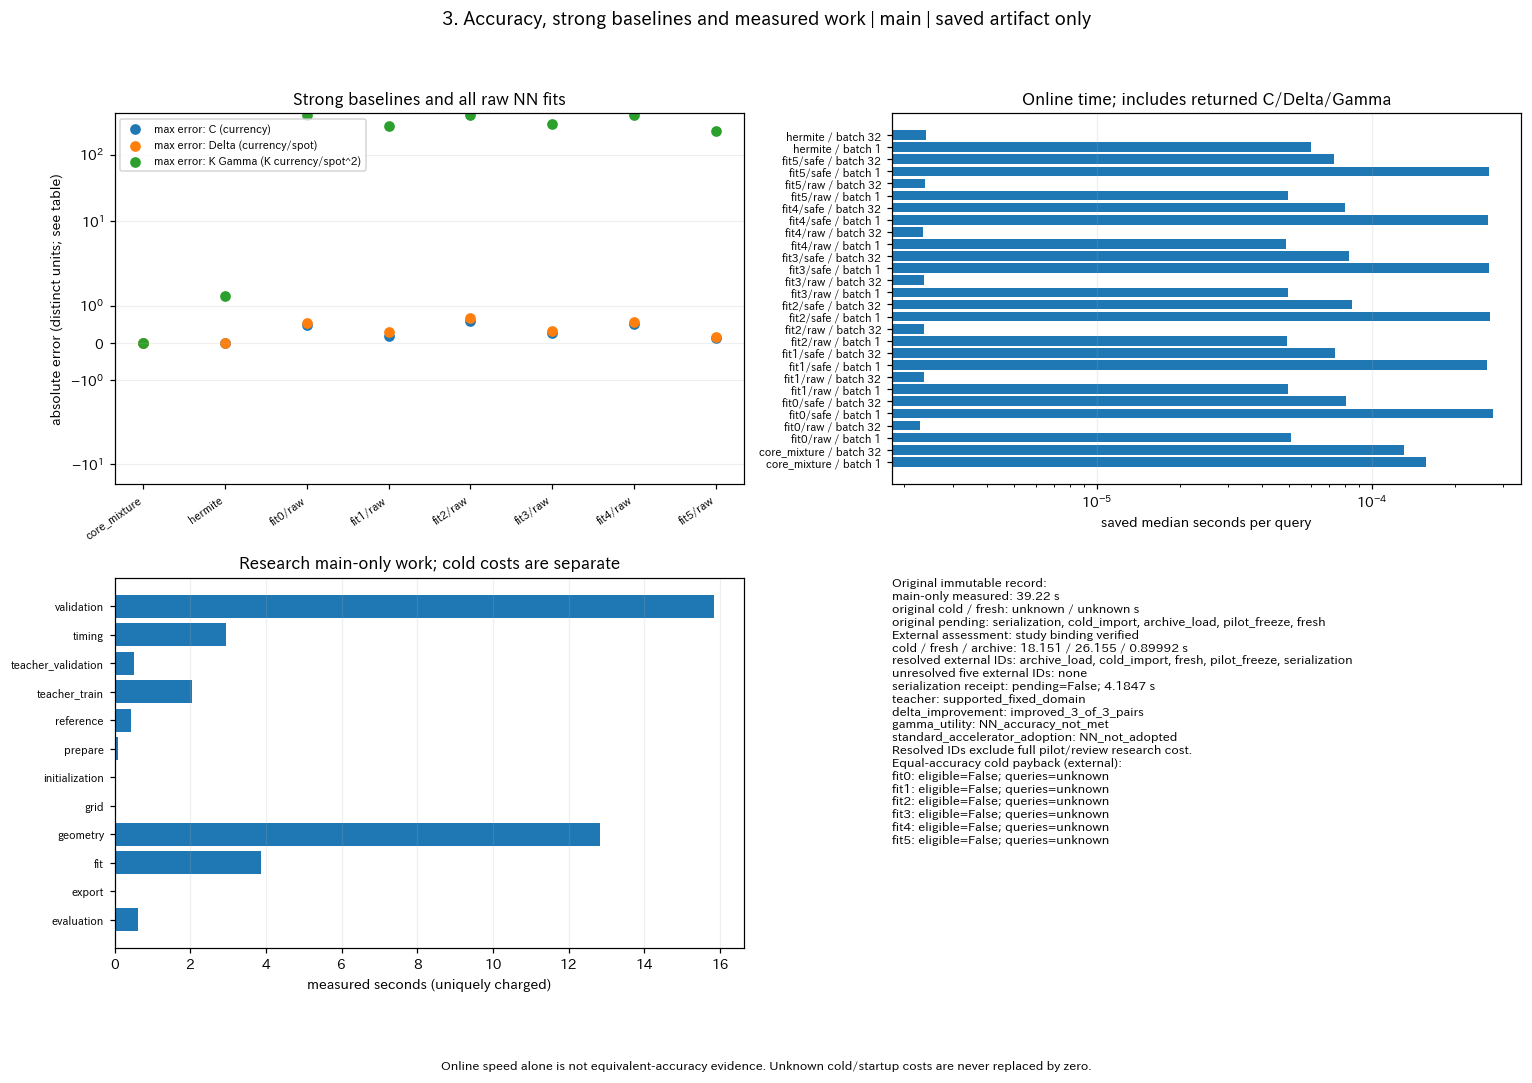

| method | original test N | failed rows | RMSE C/Delta/KGamma | p99 C/Delta/KGamma | max C/Delta/KGamma |
| --- | --- | --- | --- | --- | --- |
| core_mixture | 336 | 0 | 3.2131e-14, 2.8982e-14, 2.2573e-11 | 8.3855e-14, 1.1121e-13, 1.2771e-10 | 8.9262e-14, 2.6035e-13, 1.4984e-10 |
| hermite | 336 | 0 | 0.00011369, 9.8621e-05, 0.16747 | 0.00041995, 0.00039558, 0.94286 | 0.00046117, 0.00055332, 1.2461 |
| fit0/raw | 336 | 0 | 0.096859, 0.18493, 60.453 | 0.43786, 0.52602, 333.25 | 0.47175, 0.54274, 388.68 |
| fit1/raw | 336 | 0 | 0.040505, 0.063156, 43.908 | 0.10735, 0.21321, 214.51 | 0.17226, 0.27587, 267.99 |
| fit2/raw | 336 | 0 | 0.11156, 0.21095, 62.081 | 0.45572, 0.62754, 341.44 | 0.59578, 0.65398, 391.76 |
| fit3/raw | 336 | 0 | 0.042515, 0.073516, 47.214 | 0.11659, 0.27161, 242.71 | 0.27047, 0.30757, 289.31 |
| fit4/raw | 336 | 0 | 0.097101, 0.19411, 61.218 | 0.39588, 0.55086, 339.27 | 0.49511, 0.56945, 389.65 |
| fit5/raw | 336 | 0 | 0.027818, 0.046492, 34.826 | 0.091591, 0.15584, 165.15 | 0.12732, 0.16079, 222.11 |

Frozen accuracy targets (descriptive, no new adoption decision): {'delta_abs': 0.005, 'price_abs': 0.01, 'scaled_gamma_abs': 0.05, 'scaled_gamma_relative': 0.05}


| expense ID | category | charged | measured seconds | scope |
| --- | --- | --- | --- | --- |
| protocol_gate | validation | True | 6.6383 | source/conditions/seed roster and main's actual frozen pilot validation |
| geometry | geometry | True | 12.842 | original balanced train/validation and deterministic test rosters |
| reference | reference | True | 0.4438 | all core oracle rows, independent test mixture and representative density integrals |
| teacher/train/0 | teacher_train | True | 0.00011354 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/1 | teacher_train | True | 0.010912 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/2 | teacher_train | True | 9.3744e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/3 | teacher_train | True | 0.0074938 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/4 | teacher_train | True | 8.2598e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/5 | teacher_train | True | 0.0096814 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/6 | teacher_train | True | 9.2994e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/7 | teacher_train | True | 0.005139 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/8 | teacher_train | True | 7.1644e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/9 | teacher_train | True | 0.0069822 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/10 | teacher_train | True | 7.818e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/11 | teacher_train | True | 0.0096781 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/12 | teacher_train | True | 9.0685e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/13 | teacher_train | True | 0.0054938 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/14 | teacher_train | True | 7.3243e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/15 | teacher_train | True | 0.0077259 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/16 | teacher_train | True | 8.1328e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/17 | teacher_train | True | 0.0099897 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/18 | teacher_train | True | 9.2663e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/19 | teacher_train | True | 0.0052095 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/20 | teacher_train | True | 0.00011755 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/21 | teacher_train | True | 0.010347 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/22 | teacher_train | True | 9.0351e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/23 | teacher_train | True | 0.0053047 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/24 | teacher_train | True | 6.7227e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/25 | teacher_train | True | 0.0065003 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/26 | teacher_train | True | 8.3351e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/27 | teacher_train | True | 0.0064638 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/28 | teacher_train | True | 7.668e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/29 | teacher_train | True | 0.0071859 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/30 | teacher_train | True | 8.915e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/31 | teacher_train | True | 0.0096176 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/32 | teacher_train | True | 0.00010422 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/33 | teacher_train | True | 0.0072812 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/34 | teacher_train | True | 7.8595e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/35 | teacher_train | True | 0.005402 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/36 | teacher_train | True | 8.5058e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/37 | teacher_train | True | 0.0053557 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/38 | teacher_train | True | 7.3508e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/39 | teacher_train | True | 0.0052384 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/40 | teacher_train | True | 7.307e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/41 | teacher_train | True | 0.0099064 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/42 | teacher_train | True | 8.7234e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/43 | teacher_train | True | 0.010707 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/44 | teacher_train | True | 9.0359e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/45 | teacher_train | True | 0.010354 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/46 | teacher_train | True | 9.023e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/47 | teacher_train | True | 0.010552 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/48 | teacher_train | True | 0.00010266 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/49 | teacher_train | True | 0.0096998 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/50 | teacher_train | True | 8.6e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/51 | teacher_train | True | 0.0093297 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/52 | teacher_train | True | 8.9965e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/53 | teacher_train | True | 0.0078175 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/54 | teacher_train | True | 8.4235e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/55 | teacher_train | True | 0.005056 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/56 | teacher_train | True | 7.4566e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/57 | teacher_train | True | 0.010785 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/58 | teacher_train | True | 8.7888e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/59 | teacher_train | True | 0.0059259 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/60 | teacher_train | True | 8.5296e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/61 | teacher_train | True | 0.0099272 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/62 | teacher_train | True | 8.39e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/63 | teacher_train | True | 0.0050983 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/64 | teacher_train | True | 6.8156e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/65 | teacher_train | True | 0.0097316 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/66 | teacher_train | True | 8.5654e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/67 | teacher_train | True | 0.0058279 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/68 | teacher_train | True | 7.7038e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/69 | teacher_train | True | 0.0058545 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/70 | teacher_train | True | 7.095e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/71 | teacher_train | True | 0.010157 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/72 | teacher_train | True | 0.00010193 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/73 | teacher_train | True | 0.0057012 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/74 | teacher_train | True | 7.5526e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/75 | teacher_train | True | 0.010164 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/76 | teacher_train | True | 8.8787e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/77 | teacher_train | True | 0.010032 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/78 | teacher_train | True | 8.7866e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/79 | teacher_train | True | 0.0099116 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/80 | teacher_train | True | 8.7673e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/81 | teacher_train | True | 0.0052334 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/82 | teacher_train | True | 7.2537e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/83 | teacher_train | True | 0.006213 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/84 | teacher_train | True | 7.4248e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/85 | teacher_train | True | 0.0060037 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/86 | teacher_train | True | 8.5683e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/87 | teacher_train | True | 0.0093822 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/88 | teacher_train | True | 0.00010104 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/89 | teacher_train | True | 0.0064684 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/90 | teacher_train | True | 8.4897e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/91 | teacher_train | True | 0.0067478 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/92 | teacher_train | True | 7.3709e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/93 | teacher_train | True | 0.0098079 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/94 | teacher_train | True | 9.5598e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/95 | teacher_train | True | 0.0098769 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/96 | teacher_train | True | 8.3489e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/97 | teacher_train | True | 0.0099228 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/98 | teacher_train | True | 8.5028e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/99 | teacher_train | True | 0.0096635 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/100 | teacher_train | True | 0.00011163 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/101 | teacher_train | True | 0.011137 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/102 | teacher_train | True | 0.00011238 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/103 | teacher_train | True | 0.011273 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/104 | teacher_train | True | 0.00010125 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/105 | teacher_train | True | 0.008995 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/106 | teacher_train | True | 8.9892e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/107 | teacher_train | True | 0.011341 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/108 | teacher_train | True | 0.00010418 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/109 | teacher_train | True | 0.0083024 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/110 | teacher_train | True | 9.5696e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/111 | teacher_train | True | 0.0097714 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/112 | teacher_train | True | 9.0596e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/113 | teacher_train | True | 0.0052567 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/114 | teacher_train | True | 7.3138e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/115 | teacher_train | True | 0.0099963 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/116 | teacher_train | True | 9.1405e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/117 | teacher_train | True | 0.009782 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/118 | teacher_train | True | 8.4456e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/119 | teacher_train | True | 0.0088136 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/120 | teacher_train | True | 8.6268e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/121 | teacher_train | True | 0.0053706 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/122 | teacher_train | True | 7.8965e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/123 | teacher_train | True | 0.0091757 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/124 | teacher_train | True | 8.9051e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/125 | teacher_train | True | 0.010209 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/126 | teacher_train | True | 8.8403e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/127 | teacher_train | True | 0.0056124 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/128 | teacher_train | True | 7.1734e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/129 | teacher_train | True | 0.0064226 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/130 | teacher_train | True | 7.9226e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/131 | teacher_train | True | 0.0097913 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/132 | teacher_train | True | 8.5666e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/133 | teacher_train | True | 0.0071825 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/134 | teacher_train | True | 8.1252e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/135 | teacher_train | True | 0.010402 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/136 | teacher_train | True | 9.1359e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/137 | teacher_train | True | 0.0064967 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/138 | teacher_train | True | 8.7765e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/139 | teacher_train | True | 0.008231 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/140 | teacher_train | True | 8.9383e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/141 | teacher_train | True | 0.0099688 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/142 | teacher_train | True | 9.015e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/143 | teacher_train | True | 0.010277 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/144 | teacher_train | True | 9.8233e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/145 | teacher_train | True | 0.0085826 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/146 | teacher_train | True | 8.6158e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/147 | teacher_train | True | 0.0053098 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/148 | teacher_train | True | 7.2093e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/149 | teacher_train | True | 0.0094411 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/150 | teacher_train | True | 8.8722e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/151 | teacher_train | True | 0.0070447 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/152 | teacher_train | True | 8.0134e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/153 | teacher_train | True | 0.0050709 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/154 | teacher_train | True | 6.717e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/155 | teacher_train | True | 0.01059 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/156 | teacher_train | True | 8.5442e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/157 | teacher_train | True | 0.0063264 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/158 | teacher_train | True | 7.647e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/159 | teacher_train | True | 0.0096361 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/160 | teacher_train | True | 8.7421e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/161 | teacher_train | True | 0.0056706 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/162 | teacher_train | True | 7.197e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/163 | teacher_train | True | 0.0093695 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/164 | teacher_train | True | 8.6004e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/165 | teacher_train | True | 0.0061468 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/166 | teacher_train | True | 7.2184e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/167 | teacher_train | True | 0.0095726 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/168 | teacher_train | True | 0.00010427 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/169 | teacher_train | True | 0.0097895 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/170 | teacher_train | True | 0.0001003 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/171 | teacher_train | True | 0.0098988 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/172 | teacher_train | True | 8.0219e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/173 | teacher_train | True | 0.0052695 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/174 | teacher_train | True | 6.7924e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/175 | teacher_train | True | 0.0060326 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/176 | teacher_train | True | 6.983e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/177 | teacher_train | True | 0.0087967 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/178 | teacher_train | True | 9.6042e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/179 | teacher_train | True | 0.0095033 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/180 | teacher_train | True | 8.6792e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/181 | teacher_train | True | 0.0096488 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/182 | teacher_train | True | 8.9156e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/183 | teacher_train | True | 0.0051724 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/184 | teacher_train | True | 6.7516e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/185 | teacher_train | True | 0.005838 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/186 | teacher_train | True | 9.5661e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/187 | teacher_train | True | 0.0056248 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/188 | teacher_train | True | 7.3466e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/189 | teacher_train | True | 0.0048657 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/190 | teacher_train | True | 6.3847e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/191 | teacher_train | True | 0.0098087 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/192 | teacher_train | True | 9.023e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/193 | teacher_train | True | 0.0053752 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/194 | teacher_train | True | 8.7556e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/195 | teacher_train | True | 0.0098681 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/196 | teacher_train | True | 9.1208e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/197 | teacher_train | True | 0.0095006 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/198 | teacher_train | True | 8.3933e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/199 | teacher_train | True | 0.0099284 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/200 | teacher_train | True | 8.8717e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/201 | teacher_train | True | 0.010051 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/202 | teacher_train | True | 9.1532e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/203 | teacher_train | True | 0.0093825 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/204 | teacher_train | True | 8.5261e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/205 | teacher_train | True | 0.0093983 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/206 | teacher_train | True | 8.8373e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/207 | teacher_train | True | 0.0054477 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/208 | teacher_train | True | 7.3151e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/209 | teacher_train | True | 0.0092837 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/210 | teacher_train | True | 8.0523e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/211 | teacher_train | True | 0.0084045 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/212 | teacher_train | True | 8.0031e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/213 | teacher_train | True | 0.0062285 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/214 | teacher_train | True | 7.3091e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/215 | teacher_train | True | 0.0094804 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/216 | teacher_train | True | 8.8062e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/217 | teacher_train | True | 0.00983 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/218 | teacher_train | True | 8.3344e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/219 | teacher_train | True | 0.0064111 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/220 | teacher_train | True | 7.683e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/221 | teacher_train | True | 0.0092056 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/222 | teacher_train | True | 8.0016e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/223 | teacher_train | True | 0.0063927 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/224 | teacher_train | True | 7.8524e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/225 | teacher_train | True | 0.0055404 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/226 | teacher_train | True | 7.5558e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/227 | teacher_train | True | 0.010642 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/228 | teacher_train | True | 0.00010012 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/229 | teacher_train | True | 0.005461 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/230 | teacher_train | True | 8.9675e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/231 | teacher_train | True | 0.0078967 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/232 | teacher_train | True | 0.00010764 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/233 | teacher_train | True | 0.005975 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/234 | teacher_train | True | 7.7505e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/235 | teacher_train | True | 0.0064221 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/236 | teacher_train | True | 8.0732e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/237 | teacher_train | True | 0.0096468 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/238 | teacher_train | True | 8.3854e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/239 | teacher_train | True | 0.0052109 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/240 | teacher_train | True | 7.716e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/241 | teacher_train | True | 0.0092252 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/242 | teacher_train | True | 8.1104e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/243 | teacher_train | True | 0.010208 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/244 | teacher_train | True | 8.3944e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/245 | teacher_train | True | 0.0073573 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/246 | teacher_train | True | 7.7359e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/247 | teacher_train | True | 0.0063457 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/248 | teacher_train | True | 7.0889e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/249 | teacher_train | True | 0.0050654 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/250 | teacher_train | True | 6.5512e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/251 | teacher_train | True | 0.007182 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/252 | teacher_train | True | 7.6772e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/253 | teacher_train | True | 0.0063959 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/254 | teacher_train | True | 7.1315e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/255 | teacher_train | True | 0.0094462 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/256 | teacher_train | True | 8.9548e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/257 | teacher_train | True | 0.007199 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/258 | teacher_train | True | 7.5613e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/259 | teacher_train | True | 0.0053651 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/260 | teacher_train | True | 7.3272e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/261 | teacher_train | True | 0.0062787 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/262 | teacher_train | True | 0.0001092 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/263 | teacher_train | True | 0.0052015 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/264 | teacher_train | True | 7.6364e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/265 | teacher_train | True | 0.0065294 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/266 | teacher_train | True | 8.0745e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/267 | teacher_train | True | 0.0060165 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/268 | teacher_train | True | 8.0214e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/269 | teacher_train | True | 0.0091009 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/270 | teacher_train | True | 9.7716e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/271 | teacher_train | True | 0.0059899 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/272 | teacher_train | True | 7.9449e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/273 | teacher_train | True | 0.0082687 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/274 | teacher_train | True | 8.8538e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/275 | teacher_train | True | 0.0050909 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/276 | teacher_train | True | 7.2387e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/277 | teacher_train | True | 0.0091799 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/278 | teacher_train | True | 0.00010166 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/279 | teacher_train | True | 0.009565 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/280 | teacher_train | True | 0.00010345 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/281 | teacher_train | True | 0.0056853 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/282 | teacher_train | True | 6.539e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/283 | teacher_train | True | 0.0095904 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/284 | teacher_train | True | 9.3941e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/285 | teacher_train | True | 0.0060921 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/286 | teacher_train | True | 7.0979e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/287 | teacher_train | True | 0.0097535 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/288 | teacher_train | True | 8.5455e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/289 | teacher_train | True | 0.0092533 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/290 | teacher_train | True | 8.7488e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/291 | teacher_train | True | 0.0095459 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/292 | teacher_train | True | 8.1101e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/293 | teacher_train | True | 0.005816 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/294 | teacher_train | True | 7.2617e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/295 | teacher_train | True | 0.0058617 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/296 | teacher_train | True | 7.0335e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/297 | teacher_train | True | 0.0095341 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/298 | teacher_train | True | 8.338e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/299 | teacher_train | True | 0.005322 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/300 | teacher_train | True | 6.8798e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/301 | teacher_train | True | 0.0052569 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/302 | teacher_train | True | 7.4675e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/303 | teacher_train | True | 0.0096211 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/304 | teacher_train | True | 9.5639e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/305 | teacher_train | True | 0.0095983 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/306 | teacher_train | True | 9.6239e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/307 | teacher_train | True | 0.0097687 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/308 | teacher_train | True | 9.2e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/309 | teacher_train | True | 0.0078246 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/310 | teacher_train | True | 7.8702e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/311 | teacher_train | True | 0.0054472 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/312 | teacher_train | True | 7.5363e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/313 | teacher_train | True | 0.0092925 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/314 | teacher_train | True | 7.992e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/315 | teacher_train | True | 0.0049585 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/316 | teacher_train | True | 6.7687e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/317 | teacher_train | True | 0.0095408 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/318 | teacher_train | True | 8.5092e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/319 | teacher_train | True | 0.0098847 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/320 | teacher_train | True | 9.0857e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/321 | teacher_train | True | 0.0095688 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/322 | teacher_train | True | 8.6803e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/323 | teacher_train | True | 0.0082333 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/324 | teacher_train | True | 8.6116e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/325 | teacher_train | True | 0.0051629 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/326 | teacher_train | True | 6.6079e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/327 | teacher_train | True | 0.0092981 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/328 | teacher_train | True | 8.5073e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/329 | teacher_train | True | 0.0050999 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/330 | teacher_train | True | 6.7518e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/331 | teacher_train | True | 0.0092944 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/332 | teacher_train | True | 8.8132e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/333 | teacher_train | True | 0.0054128 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/334 | teacher_train | True | 6.8753e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/335 | teacher_train | True | 0.0094136 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/336 | teacher_train | True | 8.368e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/337 | teacher_train | True | 0.0056049 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/338 | teacher_train | True | 6.8669e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/339 | teacher_train | True | 0.0096091 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/340 | teacher_train | True | 8.7674e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/341 | teacher_train | True | 0.0056987 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/342 | teacher_train | True | 6.8055e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/343 | teacher_train | True | 0.0048887 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/344 | teacher_train | True | 6.5963e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/345 | teacher_train | True | 0.0050323 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/346 | teacher_train | True | 6.3539e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/347 | teacher_train | True | 0.0095049 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/348 | teacher_train | True | 8.6964e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/349 | teacher_train | True | 0.010166 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/350 | teacher_train | True | 9.0422e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/351 | teacher_train | True | 0.0094878 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/352 | teacher_train | True | 8.8538e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/353 | teacher_train | True | 0.010498 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/354 | teacher_train | True | 8.4449e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/355 | teacher_train | True | 0.0066867 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/356 | teacher_train | True | 7.7063e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/357 | teacher_train | True | 0.0051904 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/358 | teacher_train | True | 7.5198e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/359 | teacher_train | True | 0.0093739 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/360 | teacher_train | True | 8.66e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/361 | teacher_train | True | 0.0050271 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/362 | teacher_train | True | 6.6305e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/363 | teacher_train | True | 0.0096004 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/364 | teacher_train | True | 8.5347e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/365 | teacher_train | True | 0.0096112 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/366 | teacher_train | True | 8.4089e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/367 | teacher_train | True | 0.009625 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/368 | teacher_train | True | 8.3793e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/369 | teacher_train | True | 0.0097189 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/370 | teacher_train | True | 8.1846e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/371 | teacher_train | True | 0.0096831 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/372 | teacher_train | True | 0.00012781 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/373 | teacher_train | True | 0.014698 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/374 | teacher_train | True | 0.00011004 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/375 | teacher_train | True | 0.006002 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/376 | teacher_train | True | 7.9916e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/377 | teacher_train | True | 0.0063585 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/378 | teacher_train | True | 7.5188e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/379 | teacher_train | True | 0.0097887 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/380 | teacher_train | True | 0.0001023 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/381 | teacher_train | True | 0.0096567 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/382 | teacher_train | True | 8.2156e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/383 | teacher_train | True | 0.0052255 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/384 | teacher_train | True | 6.964e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/385 | teacher_train | True | 0.005387 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/386 | teacher_train | True | 7.7886e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/387 | teacher_train | True | 0.0055336 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/388 | teacher_train | True | 6.8463e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/389 | teacher_train | True | 0.0080353 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/390 | teacher_train | True | 8.3422e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/391 | teacher_train | True | 0.0098956 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/392 | teacher_train | True | 8.978e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/393 | teacher_train | True | 0.010113 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/394 | teacher_train | True | 8.2081e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/395 | teacher_train | True | 0.0069589 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/396 | teacher_train | True | 8.6293e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/397 | teacher_train | True | 0.009531 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/398 | teacher_train | True | 8.8958e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/399 | teacher_train | True | 0.010276 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/400 | teacher_train | True | 8.9789e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/401 | teacher_train | True | 0.0091693 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/402 | teacher_train | True | 8.5686e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/403 | teacher_train | True | 0.0083249 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/404 | teacher_train | True | 8.0503e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/405 | teacher_train | True | 0.0065162 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/406 | teacher_train | True | 7.5046e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/407 | teacher_train | True | 0.0086298 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/408 | teacher_train | True | 8.2562e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/409 | teacher_train | True | 0.009776 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/410 | teacher_train | True | 8.4642e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/411 | teacher_train | True | 0.0050729 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/412 | teacher_train | True | 6.8887e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/413 | teacher_train | True | 0.0057062 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/414 | teacher_train | True | 7.4136e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/415 | teacher_train | True | 0.0099619 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/416 | teacher_train | True | 0.00010214 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/417 | teacher_train | True | 0.0089236 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/418 | teacher_train | True | 8.5419e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/419 | teacher_train | True | 0.0067219 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/420 | teacher_train | True | 8.1806e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/421 | teacher_train | True | 0.010106 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/422 | teacher_train | True | 8.9279e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/423 | teacher_train | True | 0.0056259 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/424 | teacher_train | True | 7.1576e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/425 | teacher_train | True | 0.0076034 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/426 | teacher_train | True | 8.264e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/427 | teacher_train | True | 0.009322 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/428 | teacher_train | True | 8.3337e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/429 | teacher_train | True | 0.0096434 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/430 | teacher_train | True | 8.3196e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/431 | teacher_train | True | 0.0054477 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/432 | teacher_train | True | 6.9644e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/433 | teacher_train | True | 0.0068452 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/434 | teacher_train | True | 8.4689e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/435 | teacher_train | True | 0.0095877 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/436 | teacher_train | True | 0.00010647 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/437 | teacher_train | True | 0.0094347 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/438 | teacher_train | True | 8.669e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/439 | teacher_train | True | 0.0067636 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/440 | teacher_train | True | 7.9105e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/441 | teacher_train | True | 0.0063656 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/442 | teacher_train | True | 7.6323e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/443 | teacher_train | True | 0.0048738 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/444 | teacher_train | True | 6.8119e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/445 | teacher_train | True | 0.0097766 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/446 | teacher_train | True | 8.757e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/447 | teacher_train | True | 0.0054193 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/448 | teacher_train | True | 6.9537e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/449 | teacher_train | True | 0.0096586 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/450 | teacher_train | True | 8.5507e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/451 | teacher_train | True | 0.0094566 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/452 | teacher_train | True | 9.3153e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/453 | teacher_train | True | 0.0053997 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/454 | teacher_train | True | 7.7821e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/455 | teacher_train | True | 0.0092992 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/456 | teacher_train | True | 8.8133e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/457 | teacher_train | True | 0.0090499 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/458 | teacher_train | True | 8.8652e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/459 | teacher_train | True | 0.0054892 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/460 | teacher_train | True | 7.5306e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/461 | teacher_train | True | 0.0095642 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/462 | teacher_train | True | 8.4476e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/463 | teacher_train | True | 0.0051875 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/464 | teacher_train | True | 7.3388e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/465 | teacher_train | True | 0.0052677 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/466 | teacher_train | True | 6.7665e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/467 | teacher_train | True | 0.0092093 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/468 | teacher_train | True | 8.3013e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/469 | teacher_train | True | 0.0097334 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/470 | teacher_train | True | 8.3286e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/471 | teacher_train | True | 0.0054487 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/472 | teacher_train | True | 7.1236e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/473 | teacher_train | True | 0.0099175 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/474 | teacher_train | True | 0.00011318 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/475 | teacher_train | True | 0.0096812 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/476 | teacher_train | True | 8.7501e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/477 | teacher_train | True | 0.0067882 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/478 | teacher_train | True | 7.7217e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/479 | teacher_train | True | 0.0059479 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/480 | teacher_train | True | 7.4825e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/481 | teacher_train | True | 0.0049645 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/482 | teacher_train | True | 6.4179e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/483 | teacher_train | True | 0.0060418 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/484 | teacher_train | True | 7.0393e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/485 | teacher_train | True | 0.0094397 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/486 | teacher_train | True | 8.087e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/487 | teacher_train | True | 0.0092824 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/488 | teacher_train | True | 8.3975e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/489 | teacher_train | True | 0.0098945 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/490 | teacher_train | True | 8.4251e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/491 | teacher_train | True | 0.0060684 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/492 | teacher_train | True | 7.534e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/493 | teacher_train | True | 0.005521 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/494 | teacher_train | True | 8.0908e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/495 | teacher_train | True | 0.0082915 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/496 | teacher_train | True | 8.0141e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/497 | teacher_train | True | 0.0095089 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/498 | teacher_train | True | 8.352e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/499 | teacher_train | True | 0.010281 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/500 | teacher_train | True | 8.9237e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/501 | teacher_train | True | 0.0063461 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/502 | teacher_train | True | 7.4171e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/503 | teacher_train | True | 0.0094511 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/504 | teacher_train | True | 8.0549e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/505 | teacher_train | True | 0.0051845 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/506 | teacher_train | True | 6.7239e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/507 | teacher_train | True | 0.0050524 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/508 | teacher_train | True | 6.8031e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/509 | teacher_train | True | 0.0056052 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/510 | teacher_train | True | 6.9565e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/train/511 | teacher_train | True | 0.0098703 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/0 | teacher_validation | True | 0.00010604 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/1 | teacher_validation | True | 0.0070892 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/2 | teacher_validation | True | 8.4758e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/3 | teacher_validation | True | 0.0098527 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/4 | teacher_validation | True | 8.2629e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/5 | teacher_validation | True | 0.0052462 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/6 | teacher_validation | True | 7.1525e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/7 | teacher_validation | True | 0.0072089 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/8 | teacher_validation | True | 8.0614e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/9 | teacher_validation | True | 0.0094312 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/10 | teacher_validation | True | 0.00010072 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/11 | teacher_validation | True | 0.010219 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/12 | teacher_validation | True | 8.7942e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/13 | teacher_validation | True | 0.0058992 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/14 | teacher_validation | True | 7.9867e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/15 | teacher_validation | True | 0.0095053 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/16 | teacher_validation | True | 9.0983e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/17 | teacher_validation | True | 0.0070426 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/18 | teacher_validation | True | 7.8244e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/19 | teacher_validation | True | 0.0074431 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/20 | teacher_validation | True | 8.894e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/21 | teacher_validation | True | 0.0094317 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/22 | teacher_validation | True | 8.6862e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/23 | teacher_validation | True | 0.009845 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/24 | teacher_validation | True | 9.2444e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/25 | teacher_validation | True | 0.0055946 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/26 | teacher_validation | True | 8.2185e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/27 | teacher_validation | True | 0.0072678 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/28 | teacher_validation | True | 8.4884e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/29 | teacher_validation | True | 0.0055119 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/30 | teacher_validation | True | 8.1335e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/31 | teacher_validation | True | 0.0076977 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/32 | teacher_validation | True | 8.7739e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/33 | teacher_validation | True | 0.0080794 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/34 | teacher_validation | True | 8.4149e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/35 | teacher_validation | True | 0.009731 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/36 | teacher_validation | True | 9.0844e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/37 | teacher_validation | True | 0.0094039 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/38 | teacher_validation | True | 8.5221e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/39 | teacher_validation | True | 0.0095837 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/40 | teacher_validation | True | 8.3863e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/41 | teacher_validation | True | 0.0094477 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/42 | teacher_validation | True | 8.2765e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/43 | teacher_validation | True | 0.0094161 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/44 | teacher_validation | True | 8.9234e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/45 | teacher_validation | True | 0.0092979 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/46 | teacher_validation | True | 8.5247e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/47 | teacher_validation | True | 0.0058301 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/48 | teacher_validation | True | 0.0001107 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/49 | teacher_validation | True | 0.010055 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/50 | teacher_validation | True | 9.5859e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/51 | teacher_validation | True | 0.0098767 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/52 | teacher_validation | True | 0.00010182 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/53 | teacher_validation | True | 0.0052057 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/54 | teacher_validation | True | 6.8189e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/55 | teacher_validation | True | 0.0093466 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/56 | teacher_validation | True | 8.3494e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/57 | teacher_validation | True | 0.0050345 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/58 | teacher_validation | True | 7.1587e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/59 | teacher_validation | True | 0.0051394 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/60 | teacher_validation | True | 6.98e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/61 | teacher_validation | True | 0.0064736 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/62 | teacher_validation | True | 8.9173e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/63 | teacher_validation | True | 0.0053539 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/64 | teacher_validation | True | 7.067e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/65 | teacher_validation | True | 0.0055742 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/66 | teacher_validation | True | 8.4567e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/67 | teacher_validation | True | 0.0051503 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/68 | teacher_validation | True | 7.0524e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/69 | teacher_validation | True | 0.0091372 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/70 | teacher_validation | True | 8.6549e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/71 | teacher_validation | True | 0.0078681 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/72 | teacher_validation | True | 7.6762e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/73 | teacher_validation | True | 0.0058718 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/74 | teacher_validation | True | 7.277e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/75 | teacher_validation | True | 0.0093721 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/76 | teacher_validation | True | 8.0834e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/77 | teacher_validation | True | 0.0060399 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/78 | teacher_validation | True | 9.6249e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/79 | teacher_validation | True | 0.006217 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/80 | teacher_validation | True | 7.8693e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/81 | teacher_validation | True | 0.0054786 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/82 | teacher_validation | True | 7.3543e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/83 | teacher_validation | True | 0.011875 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/84 | teacher_validation | True | 0.00010487 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/85 | teacher_validation | True | 0.0071666 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/86 | teacher_validation | True | 7.9235e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/87 | teacher_validation | True | 0.0085885 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/88 | teacher_validation | True | 8.282e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/89 | teacher_validation | True | 0.0063792 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/90 | teacher_validation | True | 7.7867e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/91 | teacher_validation | True | 0.0070143 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/92 | teacher_validation | True | 8.1957e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/93 | teacher_validation | True | 0.0053226 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/94 | teacher_validation | True | 6.7164e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/95 | teacher_validation | True | 0.0057279 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/96 | teacher_validation | True | 7.5425e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/97 | teacher_validation | True | 0.0049208 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/98 | teacher_validation | True | 6.9953e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/99 | teacher_validation | True | 0.0086217 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/100 | teacher_validation | True | 8.4541e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/101 | teacher_validation | True | 0.0094455 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/102 | teacher_validation | True | 8.4648e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/103 | teacher_validation | True | 0.010114 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/104 | teacher_validation | True | 8.2684e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/105 | teacher_validation | True | 0.0085018 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/106 | teacher_validation | True | 8.6799e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/107 | teacher_validation | True | 0.0073867 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/108 | teacher_validation | True | 8.6646e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/109 | teacher_validation | True | 0.0054779 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/110 | teacher_validation | True | 7.2359e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/111 | teacher_validation | True | 0.0050326 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/112 | teacher_validation | True | 7.2906e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/113 | teacher_validation | True | 0.0096894 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/114 | teacher_validation | True | 8.0777e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/115 | teacher_validation | True | 0.0080801 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/116 | teacher_validation | True | 8.9597e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/117 | teacher_validation | True | 0.0093688 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/118 | teacher_validation | True | 8.3534e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/119 | teacher_validation | True | 0.0097974 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/120 | teacher_validation | True | 9.4292e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/121 | teacher_validation | True | 0.0065644 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/122 | teacher_validation | True | 8.1319e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/123 | teacher_validation | True | 0.006082 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/124 | teacher_validation | True | 7.7061e-05 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/125 | teacher_validation | True | 0.009869 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/126 | teacher_validation | True | 0.00010733 | all original count draws, active-only marks, conditional values and joint moments |
| teacher/validation/127 | teacher_validation | True | 0.011048 | all original count draws, active-only marks, conditional values and joint moments |
| hermite_grid | grid | True | 0.020391 | one grid build including all node price/Delta/Gamma oracle work |
| hermite_prepare | prepare | True | 0.078001 | saved derivatives to online quintic spline objects, charged once |
| hermite_evaluation | evaluation | True | 0.0087148 | whole predictions for all original split rows and error summaries |
| initial/0 | initialization | True | 0.011249 | recorded paired initial weights and full master batch roster; train setup separately measured |
| fit/fit0 | fit | True | 1.3266 | learner validation/setup/initialization/updates/evaluation/thread restore; shared teacher excluded |
| export/fit0 | export | True | 0.00024835 | plain copied weights/normalization/stats and in-memory NPZ fields |
| evaluation/fit0 | evaluation | True | 0.11738 | all NumPy raw/safe predictions, original errors/buckets and contract diagnostics |
| fit/fit1 | fit | True | 0.60416 | learner validation/setup/initialization/updates/evaluation/thread restore; shared teacher excluded |
| export/fit1 | export | True | 0.00014572 | plain copied weights/normalization/stats and in-memory NPZ fields |
| evaluation/fit1 | evaluation | True | 0.095847 | all NumPy raw/safe predictions, original errors/buckets and contract diagnostics |
| initial/1 | initialization | True | 0.0008268 | recorded paired initial weights and full master batch roster; train setup separately measured |
| fit/fit2 | fit | True | 0.40646 | learner validation/setup/initialization/updates/evaluation/thread restore; shared teacher excluded |
| export/fit2 | export | True | 9.3745e-05 | plain copied weights/normalization/stats and in-memory NPZ fields |
| evaluation/fit2 | evaluation | True | 0.097789 | all NumPy raw/safe predictions, original errors/buckets and contract diagnostics |
| fit/fit3 | fit | True | 0.56397 | learner validation/setup/initialization/updates/evaluation/thread restore; shared teacher excluded |
| export/fit3 | export | True | 0.00010241 | plain copied weights/normalization/stats and in-memory NPZ fields |
| evaluation/fit3 | evaluation | True | 0.10517 | all NumPy raw/safe predictions, original errors/buckets and contract diagnostics |
| initial/2 | initialization | True | 0.00074059 | recorded paired initial weights and full master batch roster; train setup separately measured |
| fit/fit4 | fit | True | 0.39881 | learner validation/setup/initialization/updates/evaluation/thread restore; shared teacher excluded |
| export/fit4 | export | True | 0.00010206 | plain copied weights/normalization/stats and in-memory NPZ fields |
| evaluation/fit4 | evaluation | True | 0.092598 | all NumPy raw/safe predictions, original errors/buckets and contract diagnostics |
| fit/fit5 | fit | True | 0.57217 | learner validation/setup/initialization/updates/evaluation/thread restore; shared teacher excluded |
| export/fit5 | export | True | 0.00024079 | plain copied weights/normalization/stats and in-memory NPZ fields |
| evaluation/fit5 | evaluation | True | 0.10052 | all NumPy raw/safe predictions, original errors/buckets and contract diagnostics |
| timing | timing | True | 2.9345 | fixed order, warmup and repeated whole calls; includes saving in-memory outputs |
| serialization | serialization | True | unknown | JSON/NPZ measured in separate record-bound serialization_cost.json |
| cold_import | cold_import | True | unknown | new-process import/startup not measured by this function |
| archive_load | archive_load | True | unknown | new archive/weights load not measured by in-memory study timing |
| pilot_freeze | pilot_freeze | True | unknown | full independent pilot/freeze outside main-only study receipt |
| fresh | fresh | True | unknown | independent fresh replay outside this saved-only study |
| saved_check | validation | True | 9.213 | all original compact/Greek/prediction/timing/cost checks, no RNG or training |

original pending cold/import/archive/pilot/fresh costs: ['serialization', 'cold_import', 'archive_load', 'pilot_freeze', 'fresh']
resolved external IDs: ['archive_load', 'cold_import', 'fresh', 'pilot_freeze', 'serialization'] | remaining original pending: []


| external cost | seconds (unknown remains unknown) |
| --- | --- |
| archive_load_s | 0.89992 |
| cold_import_s | 1.0506 |
| cold_pipeline_s | 18.151 |
| cold_prepare_s | 0.077187 |
| cold_saved_check_s | 9.1929 |
| cold_serving_s | 0.0040192 |
| failed_cold_receipt_attempt_s | 18.027 |
| fresh_cli_s | 26.444 |
| fresh_s | 26.155 |
| fresh_saved_replay_s | 14.599 |
| main_categorized_s | 39.22 |
| main_construction_cli_s | 46.085 |
| main_serialization_s | 4.1847 |
| pilot_freeze_s | 6.5905 |

| resolved external expense ID | seconds | scope | receipt |
| --- | --- | --- | --- |
| serialization | 4.1847 | NPZ compression/write and study JSON serialization/write; receipt write excluded; nested in original main CLI | serialization_cost.json |
| cold_import | 1.0506 | measured component of external fresh-interpreter cold process; nested in cold_pipeline_s, disjoint from original main run | {'path': 'cold_process_cost.json', 'component': 'cold_import_s'} |
| archive_load | 0.89992 | measured component of external fresh-interpreter cold process; nested in cold_pipeline_s, disjoint from original main run | {'path': 'cold_process_cost.json', 'component': 'archive_load_s'} |
| pilot_freeze | 6.5905 | measured component of external fresh-interpreter cold process; nested in cold_pipeline_s, disjoint from original main run | {'path': 'cold_process_cost.json', 'component': 'pilot_freeze_s'} |
| fresh | 26.155 | whole supplemental fresh function through evidence save; fresh-cost receipt write excluded; nested in separate fresh CLI, not cold or main | fresh_cost.json |

| external decision | saved assessment value |
| --- | --- |
| teacher | {"original_teacher_count": 640, "reason": "All fixed teachers precision-ready; saved independent references and additional raw validation retained.", "status": "supported_fixed_domain"} |
| delta_improvement | {"reason": "Descriptive lower raw Delta RMSE in all fixed paired seeds; not a full accuracy pass.", "status": "improved_3_of_3_pairs"} |
| gamma_utility | {"reason": "All original fits fail full-roster fixed C/Delta/KGamma pointwise accuracy; physical Gamma was not trained.", "status": "NN_accuracy_not_met"} |
| standard_accelerator_adoption | {"reason": "All 6 raw and safe fits fail equal-accuracy gate. Hermite passes all 336. Online timing cannot support equal-accuracy NN speed or payback.", "status": "NN_not_adopted"} |

| original fit | eligible | payback queries | baseline | reason | external details |
| --- | --- | --- | --- | --- | --- |
| fit0 | False | unknown | Hermite / independent mixture | Full original 336-row C/Delta/KGamma accuracy gate failed for raw and safe. Q is undefined for an ineligible comparison. | {"baseline": "Hermite / independent mixture", "eligible": false, "original_count": 336, "queries": null, "raw_passed_all_components": 0, "reason": "Full original 336-row C/Delta/KGamma accuracy gate failed for raw and safe. Q is undefined for an ineligible comparison.", "safe_passed_all_components": 193} |
| fit1 | False | unknown | Hermite / independent mixture | Full original 336-row C/Delta/KGamma accuracy gate failed for raw and safe. Q is undefined for an ineligible comparison. | {"baseline": "Hermite / independent mixture", "eligible": false, "original_count": 336, "queries": null, "raw_passed_all_components": 0, "reason": "Full original 336-row C/Delta/KGamma accuracy gate failed for raw and safe. Q is undefined for an ineligible comparison.", "safe_passed_all_components": 156} |
| fit2 | False | unknown | Hermite / independent mixture | Full original 336-row C/Delta/KGamma accuracy gate failed for raw and safe. Q is undefined for an ineligible comparison. | {"baseline": "Hermite / independent mixture", "eligible": false, "original_count": 336, "queries": null, "raw_passed_all_components": 0, "reason": "Full original 336-row C/Delta/KGamma accuracy gate failed for raw and safe. Q is undefined for an ineligible comparison.", "safe_passed_all_components": 191} |
| fit3 | False | unknown | Hermite / independent mixture | Full original 336-row C/Delta/KGamma accuracy gate failed for raw and safe. Q is undefined for an ineligible comparison. | {"baseline": "Hermite / independent mixture", "eligible": false, "original_count": 336, "queries": null, "raw_passed_all_components": 0, "reason": "Full original 336-row C/Delta/KGamma accuracy gate failed for raw and safe. Q is undefined for an ineligible comparison.", "safe_passed_all_components": 190} |
| fit4 | False | unknown | Hermite / independent mixture | Full original 336-row C/Delta/KGamma accuracy gate failed for raw and safe. Q is undefined for an ineligible comparison. | {"baseline": "Hermite / independent mixture", "eligible": false, "original_count": 336, "queries": null, "raw_passed_all_components": 0, "reason": "Full original 336-row C/Delta/KGamma accuracy gate failed for raw and safe. Q is undefined for an ineligible comparison.", "safe_passed_all_components": 182} |
| fit5 | False | unknown | Hermite / independent mixture | Full original 336-row C/Delta/KGamma accuracy gate failed for raw and safe. Q is undefined for an ineligible comparison. | {"baseline": "Hermite / independent mixture", "eligible": false, "original_count": 336, "queries": null, "raw_passed_all_components": 4, "reason": "Full original 336-row C/Delta/KGamma accuracy gate failed for raw and safe. Q is undefined for an ineligible comparison.", "safe_passed_all_components": 169} |

External assessment reports saved review/receipt conclusions; this notebook makes no new adoption decision.


In [4]:
methods = [("core_mixture", truth), ("hermite", arrays[record["hermite"]["predictions"]["test"]])]
methods += [(fit["id"] + "/raw", arrays[fit["predictions"]["test"]["raw_key"]]) for fit in fits]
comparison = [(name, analytics.error_summary(prediction, independent, strike=strike)) for name, prediction in methods]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
positions = np.arange(len(comparison))
for j, label in enumerate(units):
    axes[0, 0].scatter(positions, [np.nan if row["max"] is None else row["max"][j] for _, row in comparison],
                       label="max error: " + label)
axes[0, 0].set_xticks(positions, [name for name, _ in comparison], rotation=35, ha="right", fontsize=7)
axes[0, 0].set(yscale="symlog", ylabel="absolute error (distinct units; see table)", title="Strong baselines and all raw NN fits")
axes[0, 0].legend(fontsize=7)
online = {}
for timing in record["timing"]:
    # These are stored whole-call observations; no evaluation is timed in this notebook.
    key = (timing["method"], timing["batch_size"])
    online.setdefault(key, []).append(np.median(arrays[timing["seconds_key"]])/timing["batch_size"])
timing_keys = sorted(online)
axes[0, 1].barh(np.arange(len(timing_keys)), [np.median(online[key]) for key in timing_keys])
axes[0, 1].set_yticks(np.arange(len(timing_keys)), [name + f" / batch {batch}" for name, batch in timing_keys], fontsize=7)
axes[0, 1].set(xscale="log", xlabel="saved median seconds per query", title="Online time; includes returned C/Delta/Gamma")
totals = analytics.expense_totals(record["expenses"])
categories = sorted(totals["categories"])
axes[1, 0].barh(np.arange(len(categories)), [totals["categories"][key] for key in categories])
axes[1, 0].set_yticks(np.arange(len(categories)), categories, fontsize=7)
axes[1, 0].set(xlabel="measured seconds (uniquely charged)", title="Research main-only work; cold costs are separate")
axes[1, 1].set_axis_off()
costs = record["costs"]
pending = totals["pending_ids"]
receipt = loader.serialization_receipt(artifact_dir, record) if hasattr(loader, "serialization_receipt") else None
resolved_ids = {row["id"] for row in resolved_expenses}
remaining = [identifier for identifier in pending if identifier not in resolved_ids]
lines = ["Original immutable record:",
         "main-only measured: " + number(costs.get("main_only_s")) + " s",
         "original cold / fresh: " + number(costs.get("cold_pipeline_s")) + " / " + number(costs.get("fresh_s")) + " s",
         "original pending: " + (", ".join(pending) or "none"),
         "External assessment: " + ("unknown" if assessment is None else "study binding verified"),
         "cold / fresh / archive: " + " / ".join(number(external_costs.get(key)) for key in
              ["cold_pipeline_s", "fresh_s", "archive_load_s"]) + " s",
         "resolved external IDs: " + (", ".join(sorted(resolved_ids)) or "none"),
         "unresolved five external IDs: " + (", ".join(remaining) or "none"),
         "serialization receipt: " + ("unknown" if receipt is None else
             "pending=" + str(receipt.get("pending")) + "; " + number(receipt.get("seconds")) + " s")]
for key in ["teacher", "delta_improvement", "gamma_utility", "standard_accelerator_adoption"]:
    lines.append(key + ": " + _decision_label(external_decisions.get(key)))
lines.append("Resolved IDs exclude full pilot/review research cost.")
lines.append("Equal-accuracy cold payback (external):")
for fit in fits:
    cell = external_payback.get(fit["id"], {})
    lines.append(fit["id"] + ": eligible=" + _decision_label(cell.get("eligible")) +
                 "; queries=" + number(cell.get("queries")))
axes[1, 1].text(0, 1, "\n".join(lines), transform=axes[1, 1].transAxes, va="top", fontsize=8,
                wrap=True)
for ax in axes.flat[:3]:
    ax.grid(axis="x" if ax is not axes[0, 0] else "y", alpha=.2)
finish_figure(fig, "3. Accuracy, strong baselines and measured work",
              "Online speed alone is not equivalent-accuracy evidence. Unknown cold/startup costs are never replaced by zero.")
table(["method", "original test N", "failed rows", "RMSE C/Delta/KGamma", "p99 C/Delta/KGamma", "max C/Delta/KGamma"],
      [[name, row["original_count"], row["failed_rows"], vector(row["rmse"]), vector(row["p99"]), vector(row["max"])]
      for name, row in comparison])
print("Frozen accuracy targets (descriptive, no new adoption decision):", protocol["accuracy"])
table(["expense ID", "category", "charged", "measured seconds", "scope"],
      [[row["id"], row["category"], row["charged"], number(row["seconds"]), row.get("scope", "unknown")]
       for row in record["expenses"]])
print("original pending cold/import/archive/pilot/fresh costs:", pending)
print("resolved external IDs:", sorted(resolved_ids), "| remaining original pending:", remaining)
table(["external cost", "seconds (unknown remains unknown)"],
      [[key, number(value)] for key, value in sorted(external_costs.items())] or [["assessment", "unknown"]])
table(["resolved external expense ID", "seconds", "scope", "receipt"],
      [[row["id"], number(row["seconds"]), row["scope"], row["receipt"]] for row in resolved_expenses]
      or [["assessment", "unknown", "unknown", "unknown"]])
table(["external decision", "saved assessment value"],
      [[key, "unknown" if external_decisions.get(key) is None else json.dumps(external_decisions[key], sort_keys=True)]
       for key in ["teacher", "delta_improvement", "gamma_utility", "standard_accelerator_adoption"]])
table(["original fit", "eligible", "payback queries", "baseline", "reason", "external details"],
      [[fit["id"], _decision_label(external_payback.get(fit["id"], {}).get("eligible")),
        number(external_payback.get(fit["id"], {}).get("queries")),
        external_payback.get(fit["id"], {}).get("baseline", "unknown"),
        external_payback.get(fit["id"], {}).get("reason", "unknown"),
        json.dumps(external_payback.get(fit["id"], {}), sort_keys=True)] for fit in fits])
print("External assessment reports saved review/receipt conclusions; this notebook makes no new adoption decision.")


## 読み方と限界

これは保存済み JSON/NPZ の表示です。乱数生成・較正・学習・ネットワークアクセスは実行しません。
数値再検算、教材の表示確認、独立研究受入、標準加速器への採用は別の判断です。

- 条件付き教師は元のゼロ事象を含む全 IID 分母で集計します。予約件数を実際の MC 件数と呼びません。
- 個票の価格・Delta を期待値の上限でクリップしていません。rare-event 未観測は誤差ゼロの証拠ではありません。
- raw NN と安全経路を分けます。満期 ATM の通常 Delta/Gamma は未定義、無効契約は無効のままです。
- Gamma は物理 Gamma の診断であり、Gamma 学習や実市場の 0DTE 較正を主張しません。
- 失敗した学習・非有限値は元の分母に残り、全分母の誤差を unknown と表示します。
- smoke/fixture は配線の検証だけです。速度比較には精度同等性、cold 費用、未測定費用の解消が必要です。
- 任意の `assessment.json` は record/arrays/protocol のidentity一致後に別表で表示します。元recordの受入・pending値を変更しません。
- 外部費用・採否・paybackは保存された結論であり、このnotebookが採否や未測定費用を推定したものではありません。

出典はこの保存物の `protocol` と `source_registry`、正式仕様
`2026-10-09-short-maturity-dml-design.md`、計画 `2026-10-09-short-maturity-dml.md` です。
